# 🚗 Car Price Prediction Using Machine Learning

### Oasis Infobyte — Data Science Internship
### Task 3: Car Price Prediction

**Author:** Himanshu Chavda  
**Track:** Data Science  
**Internship:** Oasis Infobyte SIP  
**Project Type:** Supervised Machine Learning — Regression

---

## 📌 Project Overview

This project develops an end-to-end machine learning system for predicting the
selling price of used cars from vehicle characteristics and specifications.

The dataset contains information related to:

- Vehicle brand and model
- Manufacturing year
- Kilometers driven
- Fuel type
- Transmission
- Location
- Ownership
- Seller type
- Engine capacity
- Maximum power
- Maximum torque
- Drivetrain
- Vehicle dimensions

### 🎯 Target Variable

**Price** — the selling price of a used vehicle.

### 💡 Business Objective

Used-car valuation depends on multiple interacting factors. A machine learning
model can learn patterns from historical vehicle data and provide a consistent
data-driven estimate of vehicle prices.

Potential applications include:

- Used-car price estimation
- Dealership pricing support
- Customer price comparison
- Automotive marketplace analytics
- Vehicle valuation systems

### 🧠 Machine Learning Approach

The project follows a complete machine learning workflow:

**Data Understanding → Data Cleaning → Feature Engineering → Exploratory Data Analysis →  
Preprocessing → Feature Encoding → Train/Test Split → Model Training →  
Model Evaluation → Model Comparison → Feature Importance → Model Persistence → Conclusion**

### 🤖 Models

Two regression algorithms are evaluated:

1. **Linear Regression** — baseline regression model
2. **Random Forest Regressor** — nonlinear ensemble model

### 📊 Evaluation Metrics

Models are evaluated using:

- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **R² Score** — coefficient of determination

The model with the strongest overall performance on unseen test data is selected
as the final model.

## 1. Problem Statement

Determining the fair selling price of a used car is influenced by multiple
factors such as age, mileage, brand, fuel type, transmission, engine capacity,
performance, ownership history, and vehicle condition.

Manual price estimation can be subjective and inconsistent.

Therefore, this project aims to build a supervised machine learning regression
model capable of predicting the selling price of used cars from historical
vehicle data.

### Problem Type

**Supervised Learning → Regression**

### Input

Vehicle characteristics and specifications.

### Output

Predicted used-car selling price.

### Success Criteria

The models will be compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model will be selected based on its overall predictive
performance.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import warnings

warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

# Machine Learning - preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Machine Learning - models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Machine Learning - evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model persistence
import joblib

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project Configuration

The following configuration values keep important project settings centralized
and make the notebook easier to maintain and reproduce.

In [2]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

DATA_PATH = "../data/car_data.csv"
IMAGE_PATH = "../images/"
OUTPUT_PATH = "../outputs/"
MODEL_PATH = "../models/"

TARGET_COLUMN = "Price"
CURRENT_YEAR = 2026

RANDOM_STATE = 42

TEST_SIZE = 0.20

print("Project configuration loaded successfully.")
print(f"Target variable : {TARGET_COLUMN}")
print(f"Test size       : {TEST_SIZE}")
print(f"Random state    : {RANDOM_STATE}")

Project configuration loaded successfully.
Target variable : Price
Test size       : 0.2
Random state    : 42


## 3. Load Dataset

The dataset contains used-car information including vehicle identity,
pricing, manufacturing year, mileage, fuel type, transmission, ownership,
engine specifications, performance, drivetrain, and physical dimensions.

The dataset is loaded using Pandas for further analysis and preprocessing.

In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (2059, 20)


### 3.1 Dataset Preview

Before performing any transformation, we inspect the first few records to
understand the structure and format of the available features.

In [4]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


### 3.2 Random Sample

A random sample provides an additional view of the dataset and helps confirm
that records are not being interpreted only from the beginning of the file.

In [5]:
df.sample(5, random_state=RANDOM_STATE)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
1298,BMW,X5 xDrive 30d Expedition,4800000,2017,35000,Diesel,Automatic,Delhi,Black,First,Individual,2993 cc,258 bhp @ 4000 rpm,560 Nm @ 1500 rpm,AWD,4886.0,1938.0,1762.0,7.0,NaN
591,Maruti Suzuki,Vitara Brezza VDi,825000,2018,48174,Diesel,Manual,Thane,White,First,Individual,1248 cc,89 bhp @ 4000 rpm,200 Nm @ 1750 rpm,FWD,3995.0,1790.0,1640.0,5.0,48.0
1318,Maruti Suzuki,Baleno Zeta 1.3,695000,2016,68921,Diesel,Manual,Hyderabad,Red,First,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1745.0,1500.0,5.0,37.0
1067,Skoda,Rapid Ambition 1.6 TDI CR MT,950000,2019,32809,Diesel,Manual,Coimbatore,Silver,First,Individual,1598 cc,105 bhp @ 4400 rpm,250 Nm @ 2500 rpm,FWD,4386.0,1699.0,1466.0,5.0,55.0
29,Honda,WR-V VX MT Petrol,819999,2018,27963,Petrol,Manual,Delhi,White,First,Individual,1199 cc,89 bhp @ 6000 rpm,110 Nm @ 4800 rpm,FWD,3999.0,1734.0,1601.0,5.0,40.0


### 3.3 Dataset Dimensions

We inspect the number of observations and features available for modelling.

In [6]:
rows, columns = df.shape

print(f"Number of rows    : {rows:,}")
print(f"Number of columns : {columns:,}")

Number of rows    : 2,059
Number of columns : 20


### 3.4 Data Types and Structure

Understanding data types is essential before cleaning and feature engineering.

Categorical features such as fuel type and transmission require different
preprocessing from numerical features such as year and kilometers driven.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

### 3.5 Column Names

We inspect the column names to identify naming inconsistencies and prepare
the dataset for reliable feature selection.

In [8]:
print("Dataset columns:\n")

for index, column in enumerate(df.columns, start=1):
    print(f"{index:02d}. {column}")

Dataset columns:

01. Make
02. Model
03. Price
04. Year
05. Kilometer
06. Fuel Type
07. Transmission
08. Location
09. Color
10. Owner
11. Seller Type
12. Engine
13. Max Power
14. Max Torque
15. Drivetrain
16. Length
17. Width
18. Height
19. Seating Capacity
20. Fuel Tank Capacity


### 3.6 Descriptive Statistics

Descriptive statistics help us understand the distribution and scale of
numerical variables.

Important statistics include:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,2059.0,1.702992e+06,2.419881e+06,49000.0,484999.00,825000.0,1925000.0,35000000.0
Year,2059.0,2.016425e+03,3.363564e+00,1988.0,2014.00,2017.0,2019.0,2022.0
Kilometer,2059.0,5.422471e+04,5.736172e+04,0.0,29000.00,50000.0,72000.0,2000000.0
Length,1995.0,4.280861e+03,4.424585e+02,3099.0,3985.00,4370.0,4629.0,5569.0
Width,1995.0,1.767992e+03,1.352658e+02,1475.0,1695.00,1770.0,1831.5,2220.0
Height,1995.0,1.591735e+03,1.360740e+02,1165.0,1485.00,1545.0,1675.0,1995.0
Seating Capacity,1995.0,5.306266e+00,8.221701e-01,2.0,5.00,5.0,5.0,8.0
Fuel Tank Capacity,1946.0,5.200221e+01,1.511020e+01,15.0,41.25,50.0,60.0,105.0


## 4. Data Quality Assessment

### 4.1 Missing Value Analysis

Missing values can negatively affect statistical analysis and machine learning
models.

We identify missing values in each column before deciding how they should be
handled.

In [10]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage
Drivetrain,136,6.61
Fuel Tank Capacity,113,5.49
Max Torque,80,3.89
Max Power,80,3.89
Engine,80,3.89
Seating Capacity,64,3.11
Height,64,3.11
Width,64,3.11
Length,64,3.11


In [11]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

### 4.2 Duplicate Record Analysis

Duplicate records can introduce bias into model training and may cause the
same observation to influence the model more than once.

We therefore identify duplicate rows before continuing with the analysis.

In [12]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count:,}")

Duplicate rows found: 0


In [13]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataset shape after duplicate removal: {df.shape}") 

Dataset shape after duplicate removal: (2059, 20)


### 4.3 Column Name Standardization

Column names containing unnecessary spaces can make feature selection and
programmatic analysis error-prone.

We standardize whitespace while preserving meaningful column names.

In [14]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine', 'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']


### 4.4 Categorical Value Cleaning

Categorical variables may contain inconsistent formatting such as:

- `"Petrol"`
- `"petrol"`
- `" PETROL "`

These represent the same category but would otherwise be treated as different
values by a machine learning algorithm.

We therefore remove unnecessary whitespace and standardize capitalization.

In [15]:
categorical_columns = [
    "Make",
    "Model",
    "Fuel Type",
    "Transmission",
    "Location",
    "Color",
    "Owner",
    "Seller Type",
    "Drivetrain"
]

for column in categorical_columns:
    if column in df.columns:
        df[column] = (
            df[column]
            .astype("string")
            .str.strip()
        )

print("Categorical formatting cleaned successfully.")

Categorical formatting cleaned successfully.


In [16]:
for column in [
    "Fuel Type",
    "Transmission",
    "Owner",
    "Seller Type",
    "Drivetrain"
]:
    if column in df.columns:
        df[column] = df[column].str.title()

print("Categorical values standardized successfully.")

Categorical values standardized successfully.


## 5. Feature Engineering

### 5.1 Converting Vehicle Specifications

Several vehicle specifications are stored as text with units or additional
information.

Examples:

- Engine: `1248 cc`
- Max Power: `74 bhp @ 4000 rpm`
- Max Torque: `190 Nm @ 2000 rpm`

Machine learning algorithms require numerical representations, so we extract
the relevant numerical values while removing textual units.

In [17]:
# Engine capacity
if "Engine" in df.columns:
    df["Engine"] = (
        df["Engine"]
        .astype("string")
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

# Maximum power
if "Max Power" in df.columns:
    df["Max Power"] = (
        df["Max Power"]
        .astype("string")
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

# Maximum torque
if "Max Torque" in df.columns:
    df["Max Torque"] = (
        df["Max Torque"]
        .astype("string")
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

print("Vehicle specification columns converted successfully.")

Vehicle specification columns converted successfully.


### 5.2 Validate Converted Features

After converting text-based specifications into numerical features, we inspect
their values to ensure the transformation was successful.

In [18]:
columns_to_check = [
    column
    for column in ["Engine", "Max Power", "Max Torque"]
    if column in df.columns
]

df[columns_to_check].head(10)

,Engine,Max Power,Max Torque
0,1198.0,87.0,109.0000
1,1248.0,74.0,190.0000
2,1197.0,79.0,112.7619
3,1197.0,82.0,113.0000
4,2393.0,148.0,343.0000
5,1373.0,91.0,130.0000
6,1991.0,181.0,300.0000
7,1995.0,188.0,400.0000
8,1798.0,177.0,250.0000
9,1461.0,84.0,200.0000


In [19]:
df[columns_to_check].describe().T

,count,mean,std,min,25%,50%,75%,max
Engine,1979.0,1692.575543,643.736294,624.0,1197.0,1498.0,1995.0,6592.0
Max Power,1979.0,129.611774,65.073797,35.0,83.0,116.0,171.0,660.0
Max Torque,1979.0,245.851019,140.465731,48.0,115.0,200.0,350.0,780.0


### 5.3 Car Age Feature

Vehicle age is an important factor in used-car valuation.

Generally, newer vehicles tend to retain more of their original value than
older vehicles, although brand, mileage, condition, and specifications also
influence the final price.

We calculate:

**Car Age = Current Year − Manufacturing Year**

In [20]:
df["Car Age"] = CURRENT_YEAR - df["Year"]

print("Car Age feature created successfully.")

df[["Year", "Car Age"]].head()

Car Age feature created successfully.


,Year,Car Age
0,2017,9
1,2014,12
2,2011,15
3,2019,7
4,2018,8


In [21]:
print("Car Age summary:")

print(df["Car Age"].describe())

Car Age summary:
count    2059.000000
mean        9.574551
std         3.363564
min         4.000000
25%         7.000000
50%         9.000000
75%        12.000000
max        38.000000
Name: Car Age, dtype: float64


In [22]:
invalid_age = df[
    (df["Car Age"] < 0) |
    (df["Car Age"] > 100)
]

print(f"Potentially invalid age records: {len(invalid_age):,}")

Potentially invalid age records: 0


### 5.4 Brand Extraction

The dataset contains separate `Make` and `Model` columns.

The `Make` column represents the vehicle manufacturer/brand, so we create a
dedicated `Brand` feature to make the business interpretation explicit.

Examples:

- Maruti Suzuki → Brand
- Hyundai → Brand
- Honda → Brand
- Toyota → Brand

In [23]:
df["Brand"] = df["Make"]

print("Brand feature created successfully.")

df["Brand"].value_counts().head(15)

Brand feature created successfully.


Brand
Maruti Suzuki    440
Hyundai          349
Mercedes-Benz    171
Honda            158
Toyota           132
Audi             127
BMW              121
Mahindra         119
Tata              57
Volkswagen        50
Ford              48
Renault           43
Skoda             40
Land Rover        33
Kia               23
Name: count, dtype: Int64

## 6. Target Variable Analysis

The target variable is `Price`, representing the selling price of the used car.

Before modelling, we verify its data type and inspect its statistical
distribution.

In [24]:
print("Target variable:", TARGET_COLUMN)
print("Data type:", df[TARGET_COLUMN].dtype)
print("Missing values:", df[TARGET_COLUMN].isnull().sum())

Target variable: Price
Data type: int64
Missing values: 0


In [25]:
df[TARGET_COLUMN].describe()

count    2.059000e+03
mean     1.702992e+06
std      2.419881e+06
min      4.900000e+04
25%      4.849990e+05
50%      8.250000e+05
75%      1.925000e+06
max      3.500000e+07
Name: Price, dtype: float64

## 7. Exploratory Data Analysis

# Visualization Theme

A consistent dark visualization theme is applied throughout the analysis to create a clean, professional, and portfolio-ready presentation.

In [26]:
# Create output directory
IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# Seaborn theme
sns.set_theme(
    style="darkgrid",
    context="notebook"
)

# Matplotlib configuration
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # Background
    "figure.facecolor": "#0F172A",
    "axes.facecolor": "#111827",

    # Text
    "text.color": "#F8FAFC",
    "axes.labelcolor": "#E2E8F0",
    "axes.titlecolor": "#F8FAFC",

    # Titles
    "axes.titleweight": "bold",
    "axes.titlesize": 18,

    # Labels
    "axes.labelsize": 12,

    # Ticks
    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Axes
    "axes.edgecolor": "#334155",

    # Grid
    "grid.color": "#334155",
    "grid.alpha": 0.30,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,

    # Legend
    "legend.fontsize": 10,

    # Save
    "savefig.facecolor": "#0F172A",
    "savefig.edgecolor": "#0F172A"
})

print("visualization environment configured successfully.")

visualization environment configured successfully.


In [27]:
# ============================================================
# PROFESSIONAL COLOR PALETTE
# ============================================================

CAR_COLORS = {
    "primary": "#38BDF8",
    "secondary": "#8B5CF6",
    "success": "#10B981",
    "warning": "#F59E0B",
    "danger": "#EF4444",
    "info": "#06B6D4",

    "petrol": "#38BDF8",
    "diesel": "#F59E0B",
    "cng": "#10B981",
    "electric": "#8B5CF6",

    "text": "#F8FAFC",
    "muted": "#94A3B8",
    "grid": "#334155",
    "background": "#0F172A",
    "axes": "#111827"
}

print("Car price prediction color palette loaded successfully.")

Car price prediction color palette loaded successfully.


In [28]:
# ============================================================
# REUSABLE CHART FORMATTING FUNCTION
# ============================================================

def format_car_chart(
    title,
    xlabel=None,
    ylabel=None,
    grid_axis="both"
):
    """
    Apply consistent professional formatting to Task 3 charts.
    """

    ax = plt.gca()

    # Title
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        color=CAR_COLORS["text"],
        pad=18
    )

    # Axis labels
    if xlabel:
        ax.set_xlabel(
            xlabel,
            fontsize=12,
            fontweight="medium",
            color=CAR_COLORS["text"],
            labelpad=10
        )

    if ylabel:
        ax.set_ylabel(
            ylabel,
            fontsize=12,
            fontweight="medium",
            color=CAR_COLORS["text"],
            labelpad=10
        )

    # Tick labels
    ax.tick_params(
        axis="both",
        colors=CAR_COLORS["muted"],
        labelsize=10
    )

    # Grid
    ax.grid(
        True,
        axis=grid_axis,
        color=CAR_COLORS["grid"],
        linestyle="--",
        linewidth=0.7,
        alpha=0.30
    )

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Keep subtle left/bottom borders
    ax.spines["left"].set_color(CAR_COLORS["grid"])
    ax.spines["bottom"].set_color(CAR_COLORS["grid"])

    # Layout
    plt.tight_layout()

### 7.1 Distribution of Used Car Selling Prices

Understanding the distribution of the target variable (**Price**) is an important
first step before building a machine learning model.

This visualization helps identify:

- The overall distribution of used car prices.
- Whether the data is positively or negatively skewed.
- The presence of potential outliers.
- The concentration of vehicles within different price ranges.

A Kernel Density Estimation (KDE) curve is included to better visualize the
underlying probability distribution of selling prices.

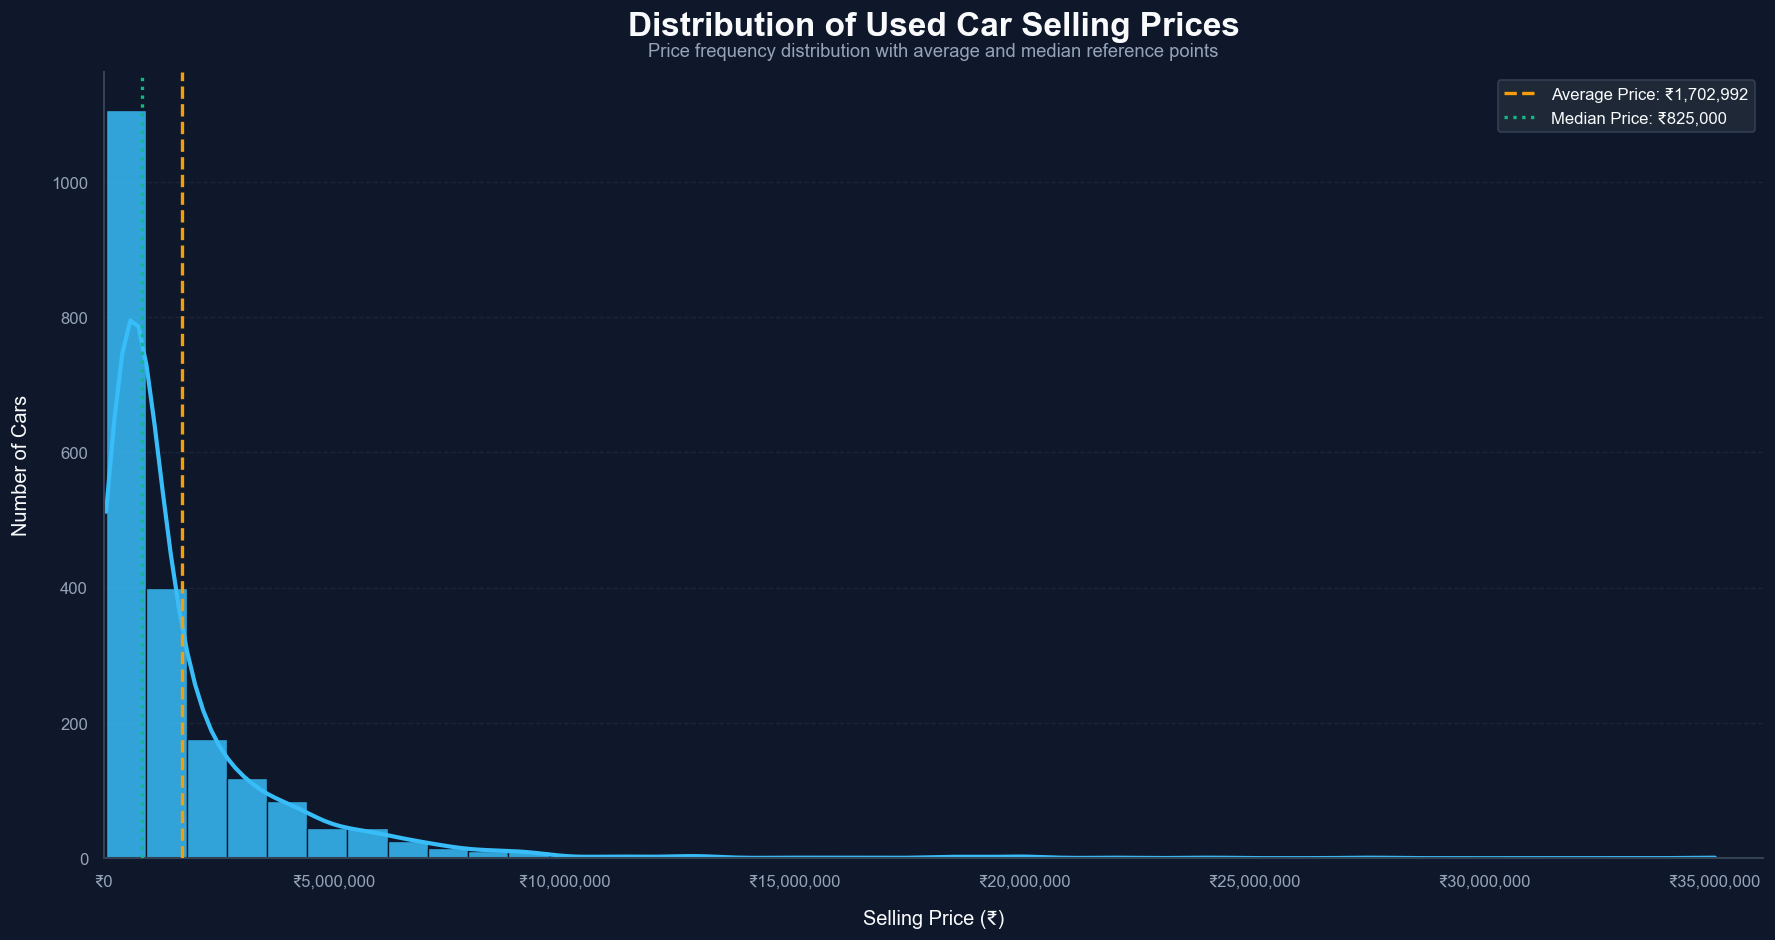

PRICE DISTRIBUTION ANALYSIS
Number of Cars : 2,059
Minimum Price  : ₹49,000
Maximum Price  : ₹35,000,000
Average Price  : ₹1,702,992
Median Price   : ₹825,000
------------------------------------------------------------
Chart saved successfully: ..\images\price_distribution.png


In [29]:
# ============================================================
# DISTRIBUTION OF USED CAR SELLING PRICES
# ============================================================

# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 8))

# Explicitly set professional dark background
fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["background"])


# ============================================================
# PRICE DISTRIBUTION
# ============================================================

sns.histplot(
    data=df,
    x="Price",
    bins=40,
    kde=True,
    color=CAR_COLORS["primary"],
    edgecolor=CAR_COLORS["background"],
    linewidth=0.8,
    alpha=0.85,
    ax=ax,
    line_kws={
        "color": CAR_COLORS["warning"],
        "linewidth": 2.5
    }
)


# ============================================================
# CALCULATE STATISTICS
# ============================================================

average_price = df["Price"].mean()
median_price = df["Price"].median()


# ============================================================
# MEAN PRICE LINE
# ============================================================

ax.axvline(
    average_price,
    color=CAR_COLORS["warning"],
    linewidth=2,
    linestyle="--",
    label=f"Average Price: ₹{average_price:,.0f}",
    zorder=4
)


# ============================================================
# MEDIAN PRICE LINE
# ============================================================

ax.axvline(
    median_price,
    color=CAR_COLORS["success"],
    linewidth=2,
    linestyle=":",
    label=f"Median Price: ₹{median_price:,.0f}",
    zorder=4
)


# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Distribution of Used Car Selling Prices",
    fontsize=20,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=22
)


# ============================================================
# SUBTITLE
# ============================================================

ax.text(
    0.5,
    1.015,
    "Price frequency distribution with average and median reference points",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=CAR_COLORS["muted"]
)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Selling Price (₹)",
    fontsize=12,
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Number of Cars",
    fontsize=12,
    color=CAR_COLORS["text"],
    labelpad=12
)


# ============================================================
# X-AXIS PRICE FORMATTING
# ============================================================

ax.tick_params(
    axis="x",
    colors=CAR_COLORS["muted"],
    labelsize=10
)

ax.tick_params(
    axis="y",
    colors=CAR_COLORS["muted"],
    labelsize=10
)

# Format x-axis values with commas
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"₹{value:,.0f}"
    )
)


# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

ax.grid(
    axis="x",
    visible=False
)


# ============================================================
# AXIS SPINES
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(
    CAR_COLORS["grid"]
)

ax.spines["bottom"].set_color(
    CAR_COLORS["grid"]
)


# ============================================================
# LEGEND
# ============================================================

legend = ax.legend(
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    fontsize=10
)

# Legend background
legend.get_frame().set_facecolor("#1F2937")
legend.get_frame().set_edgecolor(
    CAR_COLORS["grid"]
)

# Legend text
for text in legend.get_texts():
    text.set_color(
        CAR_COLORS["text"]
    )


# ============================================================
# PRICE RANGE
# ============================================================

price_min = df["Price"].min()
price_max = df["Price"].max()

price_padding = (price_max - price_min) * 0.03

ax.set_xlim(
    max(0, price_min - price_padding),
    price_max + price_padding
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# SAVE HIGH-RESOLUTION IMAGE
# ============================================================

output_path = IMAGES_DIR / "price_distribution.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"],
    edgecolor="none"
)


# ============================================================
# DISPLAY
# ============================================================

plt.show()


# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("=" * 60)
print("PRICE DISTRIBUTION ANALYSIS")
print("=" * 60)

print(f"Number of Cars : {len(df):,}")
print(f"Minimum Price  : ₹{price_min:,.0f}")
print(f"Maximum Price  : ₹{price_max:,.0f}")
print(f"Average Price  : ₹{average_price:,.0f}")
print(f"Median Price   : ₹{median_price:,.0f}")

print("-" * 60)
print(f"Chart saved successfully: {output_path}")

### 🔍 Key Observations

- Most vehicles are concentrated in the lower to mid-price range.
- The price distribution is positively skewed, with a small number of premium
  vehicles creating a long right tail.
- A few high-priced cars appear as potential outliers.
- The distribution suggests that price transformation or robust regression models
  may improve prediction performance.
- Understanding the target distribution is essential before training machine
  learning models for accurate price estimation.

# 7.2 Selling Price Distribution by Fuel Type

This visualization compares the distribution of used-car selling prices across
different fuel types.

A box plot is used to understand the:

- Median selling price
- Interquartile range (IQR)
- Overall price variation
- Potential outliers

### Why is this important?

Fuel type can influence used-car valuation because different fuel technologies
may have different purchase costs, operating costs, demand, and resale values.

The comparison helps identify whether certain fuel categories tend to have
higher or lower selling prices in the dataset.

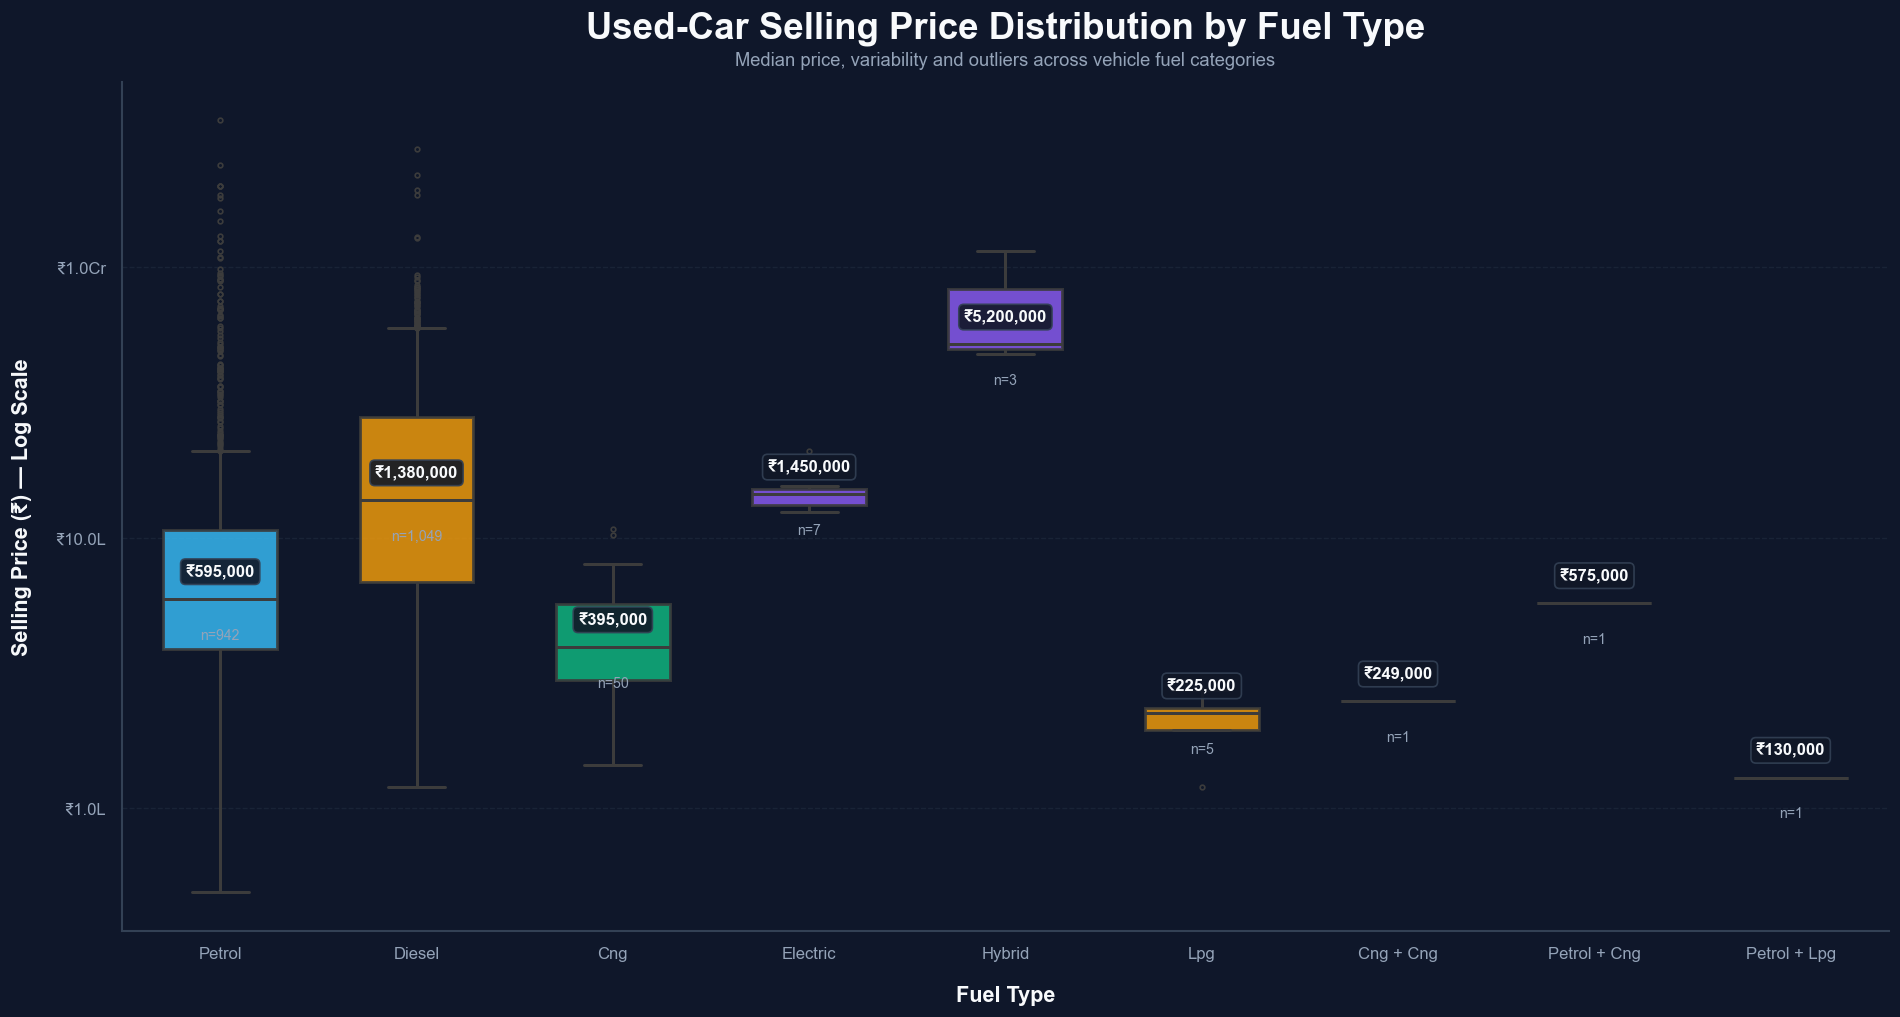

Chart saved successfully: ../images/price_by_fuel_type.png


In [30]:
# ============================================================
# 1. PREPARE DATA
# ============================================================

fuel_price_data = df[
    ["Fuel Type", "Price"]
].copy()

# Convert price to numeric
fuel_price_data["Price"] = pd.to_numeric(
    fuel_price_data["Price"],
    errors="coerce"
)

# Clean fuel type
fuel_price_data["Fuel Type"] = (
    fuel_price_data["Fuel Type"]
    .astype("string")
    .str.strip()
    .str.title()
)

# Remove invalid records
fuel_price_data = fuel_price_data.dropna(
    subset=["Fuel Type", "Price"]
)

fuel_price_data = fuel_price_data[
    fuel_price_data["Price"] > 0
].copy()

# ============================================================
# 2. DEFINE FUEL TYPE ORDER
# ============================================================

preferred_order = [
    "Petrol",
    "Diesel",
    "Cng",
    "Electric",
    "Hybrid",
    "Lpg",
    "Cng + Cng",
    "Petrol + Cng",
    "Petrol + Lpg"
]

available_fuels = [
    fuel
    for fuel in preferred_order
    if fuel in fuel_price_data["Fuel Type"].unique()
]

# Add unexpected categories automatically
remaining_fuels = sorted(
    set(fuel_price_data["Fuel Type"].unique())
    - set(available_fuels)
)

fuel_order = available_fuels + remaining_fuels

# ============================================================
# 3. SUMMARY STATISTICS
# ============================================================

fuel_summary = (
    fuel_price_data
    .groupby("Fuel Type")["Price"]
    .agg(
        Median="median",
        Count="count"
    )
    .reindex(fuel_order)
)

# ============================================================
# 4. COLOR MAPPING
# ============================================================

fuel_palette = {
    "Petrol": CAR_COLORS["petrol"],
    "Diesel": CAR_COLORS["diesel"],
    "Cng": CAR_COLORS["cng"],
    "Electric": CAR_COLORS["electric"],
    "Hybrid": CAR_COLORS["secondary"],
    "Lpg": CAR_COLORS["warning"],
    "Cng + Cng": CAR_COLORS["success"],
    "Petrol + Cng": CAR_COLORS["info"],
    "Petrol + Lpg": CAR_COLORS["primary"]
}

default_color = CAR_COLORS["primary"]

box_colors = [
    fuel_palette.get(
        fuel,
        default_color
    )
    for fuel in fuel_order
]

# ============================================================
# 5. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9)
)

fig.patch.set_facecolor(
    CAR_COLORS["background"]
)

ax.set_facecolor(
    CAR_COLORS["background"]
)

# ============================================================
# 6. BOX PLOT
# ============================================================

sns.boxplot(
    data=fuel_price_data,
    x="Fuel Type",
    y="Price",
    order=fuel_order,
    palette=box_colors,
    width=0.58,
    linewidth=1.8,
    fliersize=2.8,
    saturation=0.90,
    ax=ax
)

# ============================================================
# 7. LOGARITHMIC PRICE SCALE
# ============================================================
# The dataset contains extreme high-value cars.
# Log scale prevents those outliers from compressing
# the majority of the observations near ₹0.

ax.set_yscale("log")

# ============================================================
# 8. MEDIAN LABELS
# ============================================================

for position, fuel in enumerate(fuel_order):

    median_value = fuel_summary.loc[
        fuel,
        "Median"
    ]

    count_value = fuel_summary.loc[
        fuel,
        "Count"
    ]

    if pd.notna(median_value):

        # Small vertical offset on log scale
        label_position = median_value * 1.18

        ax.text(
            position,
            label_position,
            f"₹{median_value:,.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=CAR_COLORS["text"],
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor=CAR_COLORS["axes"],
                edgecolor=CAR_COLORS["grid"],
                alpha=0.90
            )
        )

        # Sample count below median label
        ax.text(
            position,
            median_value * 0.78,
            f"n={int(count_value):,}",
            ha="center",
            va="top",
            fontsize=8.5,
            color=CAR_COLORS["muted"]
        )

# ============================================================
# 9. TITLE
# ============================================================

ax.set_title(
    "Used-Car Selling Price Distribution by Fuel Type",
    fontsize=22,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=26
)

# ============================================================
# 10. SUBTITLE
# ============================================================

ax.text(
    0.5,
    1.015,
    "Median price, variability and outliers across vehicle fuel categories",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=CAR_COLORS["muted"]
)

# ============================================================
# 11. AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Fuel Type",
    fontsize=13,
    fontweight="bold",
    color=CAR_COLORS["text"],
    labelpad=14
)

ax.set_ylabel(
    "Selling Price (₹) — Log Scale",
    fontsize=13,
    fontweight="bold",
    color=CAR_COLORS["text"],
    labelpad=14
)

# ============================================================
# 12. X-AXIS LABELS
# ============================================================

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=10,
    color=CAR_COLORS["muted"]
)

# ============================================================
# 13. Y-AXIS PRICE FORMAT
# ============================================================

def format_indian_price(value, position):

    if value >= 1_00_00_000:
        return f"₹{value / 1_00_00_000:.1f}Cr"

    elif value >= 1_00_000:
        return f"₹{value / 1_00_000:.1f}L"

    elif value >= 1_000:
        return f"₹{value / 1_000:.0f}K"

    else:
        return f"₹{value:,.0f}"


ax.yaxis.set_major_formatter(
    FuncFormatter(format_indian_price)
)

plt.setp(
    ax.get_yticklabels(),
    color=CAR_COLORS["muted"],
    fontsize=10
)

# ============================================================
# 14. GRID
# ============================================================

ax.grid(
    axis="y",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.30
)

ax.grid(
    axis="x",
    visible=False
)

# ============================================================
# 15. SPINES
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(
    CAR_COLORS["grid"]
)

ax.spines["bottom"].set_color(
    CAR_COLORS["grid"]
)

# ============================================================
# 16. IMPROVE BOX APPEARANCE
# ============================================================

for patch, color in zip(
    ax.patches,
    box_colors
):

    patch.set_facecolor(color)
    patch.set_alpha(0.82)

# ============================================================
# 17. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

# ============================================================
# 18. SAVE HIGH-RESOLUTION IMAGE
# ============================================================

output_path = (
    "../images/"
    "price_by_fuel_type.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"],
    edgecolor=CAR_COLORS["background"]
)

plt.show()

print(
    f"Chart saved successfully: {output_path}"
)

## 🔎 Key Observation

Selling prices vary across different fuel types, with differences in median
price, spread, and outliers.

### 💡 Business Insight

Fuel type can influence used-car prices, but factors such as car age, mileage,
brand, engine, power, and transmission also affect valuation. Therefore, fuel
type will be used as one of the model's predictive features.

### 7.3 Car Age vs Selling Price

Vehicle age is expected to be an important predictor of used-car price.

This scatter plot helps us examine whether selling price tends to decrease
as vehicle age increases and whether there are unusual observations.

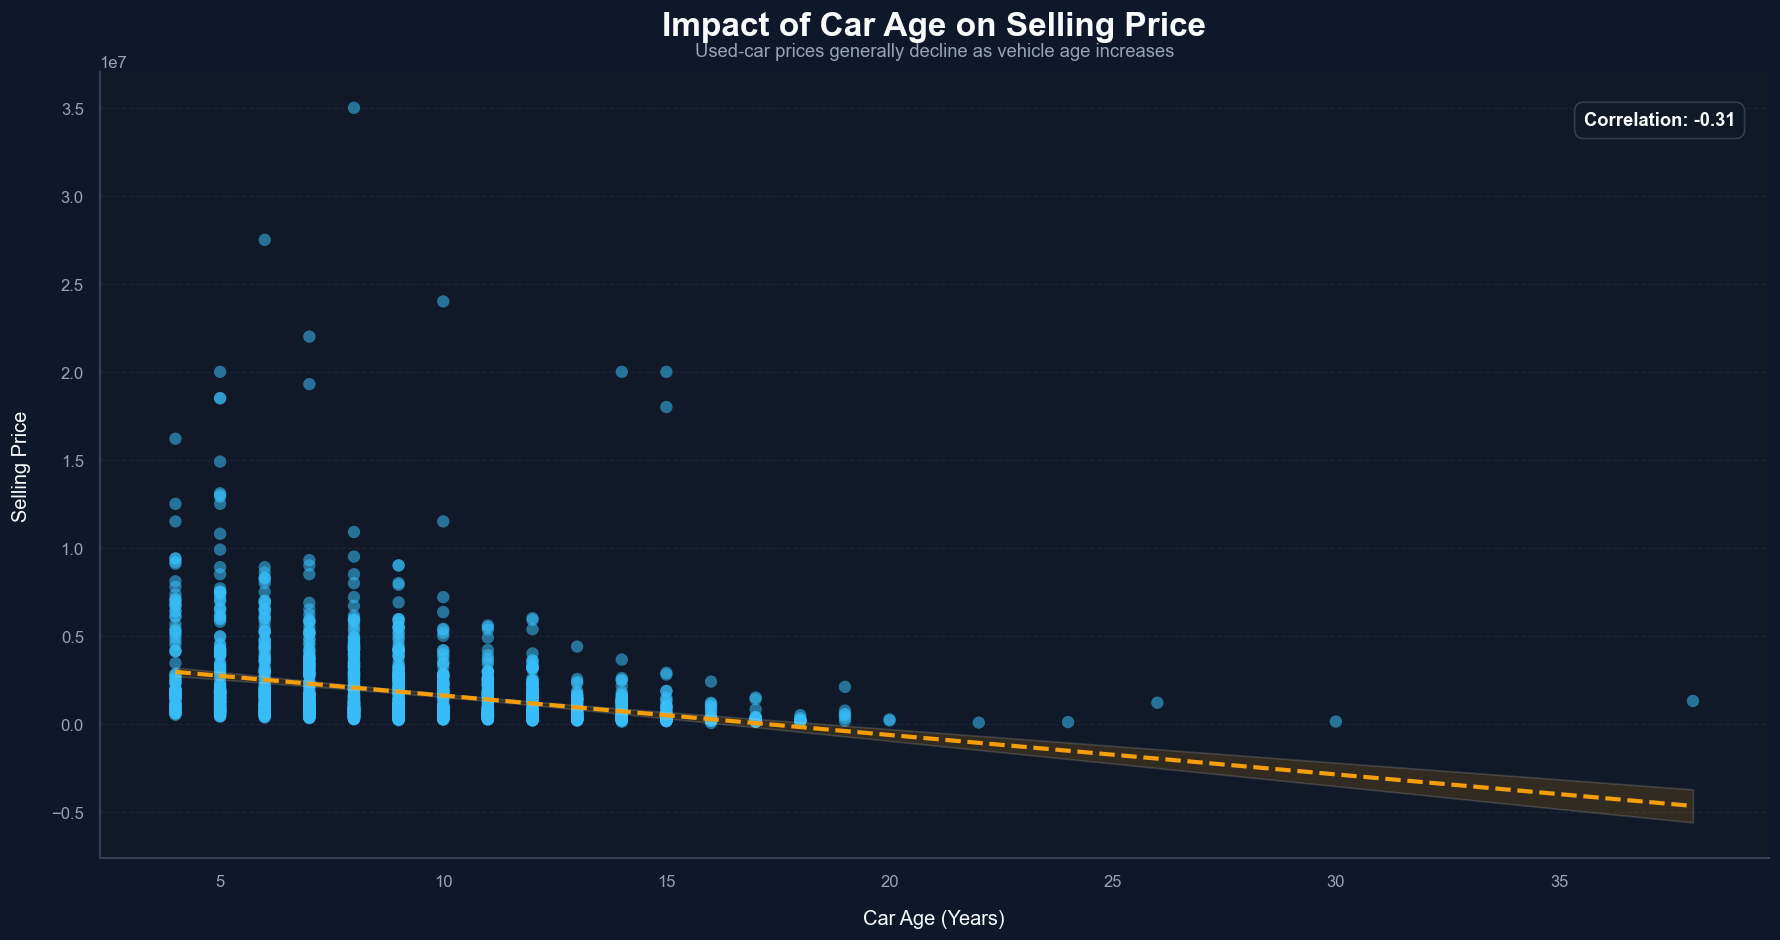

Chart saved successfully: ../images/car_age_vs_price.png


In [31]:
# ============================================================
# 03. CAR AGE VS SELLING PRICE
# ============================================================
# Purpose:
# Analyze how vehicle age is associated with its selling price.
# A regression trend line is added to make the overall relationship
# easier to interpret.
# ============================================================

# Create figure and axes
fig, ax = plt.subplots(figsize=(15, 8))

# ------------------------------------------------------------
# Background
# ------------------------------------------------------------

fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["axes"])

# ------------------------------------------------------------
# Scatter Plot
# ------------------------------------------------------------

sns.scatterplot(
    data=df,
    x="Car Age",
    y="Price",
    color=CAR_COLORS["primary"],
    alpha=0.55,
    s=55,
    edgecolor="none",
    ax=ax
)

# ------------------------------------------------------------
# Trend Line
# ------------------------------------------------------------

sns.regplot(
    data=df,
    x="Car Age",
    y="Price",
    scatter=False,
    color=CAR_COLORS["warning"],
    line_kws={
        "linewidth": 2.5,
        "linestyle": "--"
    },
    ax=ax
)

# ------------------------------------------------------------
# Calculate Correlation
# ------------------------------------------------------------

age_price_corr = df[
    ["Car Age", "Price"]
].corr().loc["Car Age", "Price"]

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Impact of Car Age on Selling Price",
    fontsize=20,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=22
)

# ------------------------------------------------------------
# Subtitle
# ------------------------------------------------------------

ax.text(
    0.5,
    1.015,
    "Used-car prices generally decline as vehicle age increases",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=CAR_COLORS["muted"]
)

# ------------------------------------------------------------
# Axis Labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Car Age (Years)",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Selling Price",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

# ------------------------------------------------------------
# Correlation Annotation
# ------------------------------------------------------------

ax.text(
    0.98,
    0.95,
    f"Correlation: {age_price_corr:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    color=CAR_COLORS["text"],
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor=CAR_COLORS["axes"],
        edgecolor=CAR_COLORS["grid"],
        alpha=0.95
    )
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(
    axis="y",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.30
)

ax.grid(
    axis="x",
    visible=False
)

# ------------------------------------------------------------
# Axis Spines
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(CAR_COLORS["grid"])
ax.spines["bottom"].set_color(CAR_COLORS["grid"])

# ------------------------------------------------------------
# Tick Formatting
# ------------------------------------------------------------

ax.tick_params(
    axis="both",
    colors=CAR_COLORS["muted"],
    labelsize=10
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save Chart
# ------------------------------------------------------------

output_path = "../images/car_age_vs_price.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔍 Key Observation

The scatter plot shows a generally negative relationship between **Car Age** and **Selling Price**, indicating that older vehicles tend to have lower selling prices.

However, the relationship is not perfectly linear. Vehicles with similar ages can have significantly different prices because other factors such as **brand, model, mileage, fuel type, transmission, engine performance, and ownership history** also affect market value.

The correlation value provides a quantitative measure of the relationship between vehicle age and selling price.

### 7.4 Kilometers Driven vs Selling Price

This visualization examines the relationship between a vehicle's total kilometers
driven and its selling price.

A downward trend would indicate that heavily driven vehicles generally have lower
market values, although factors such as brand, age, fuel type, and vehicle
condition can also influence the final selling price.

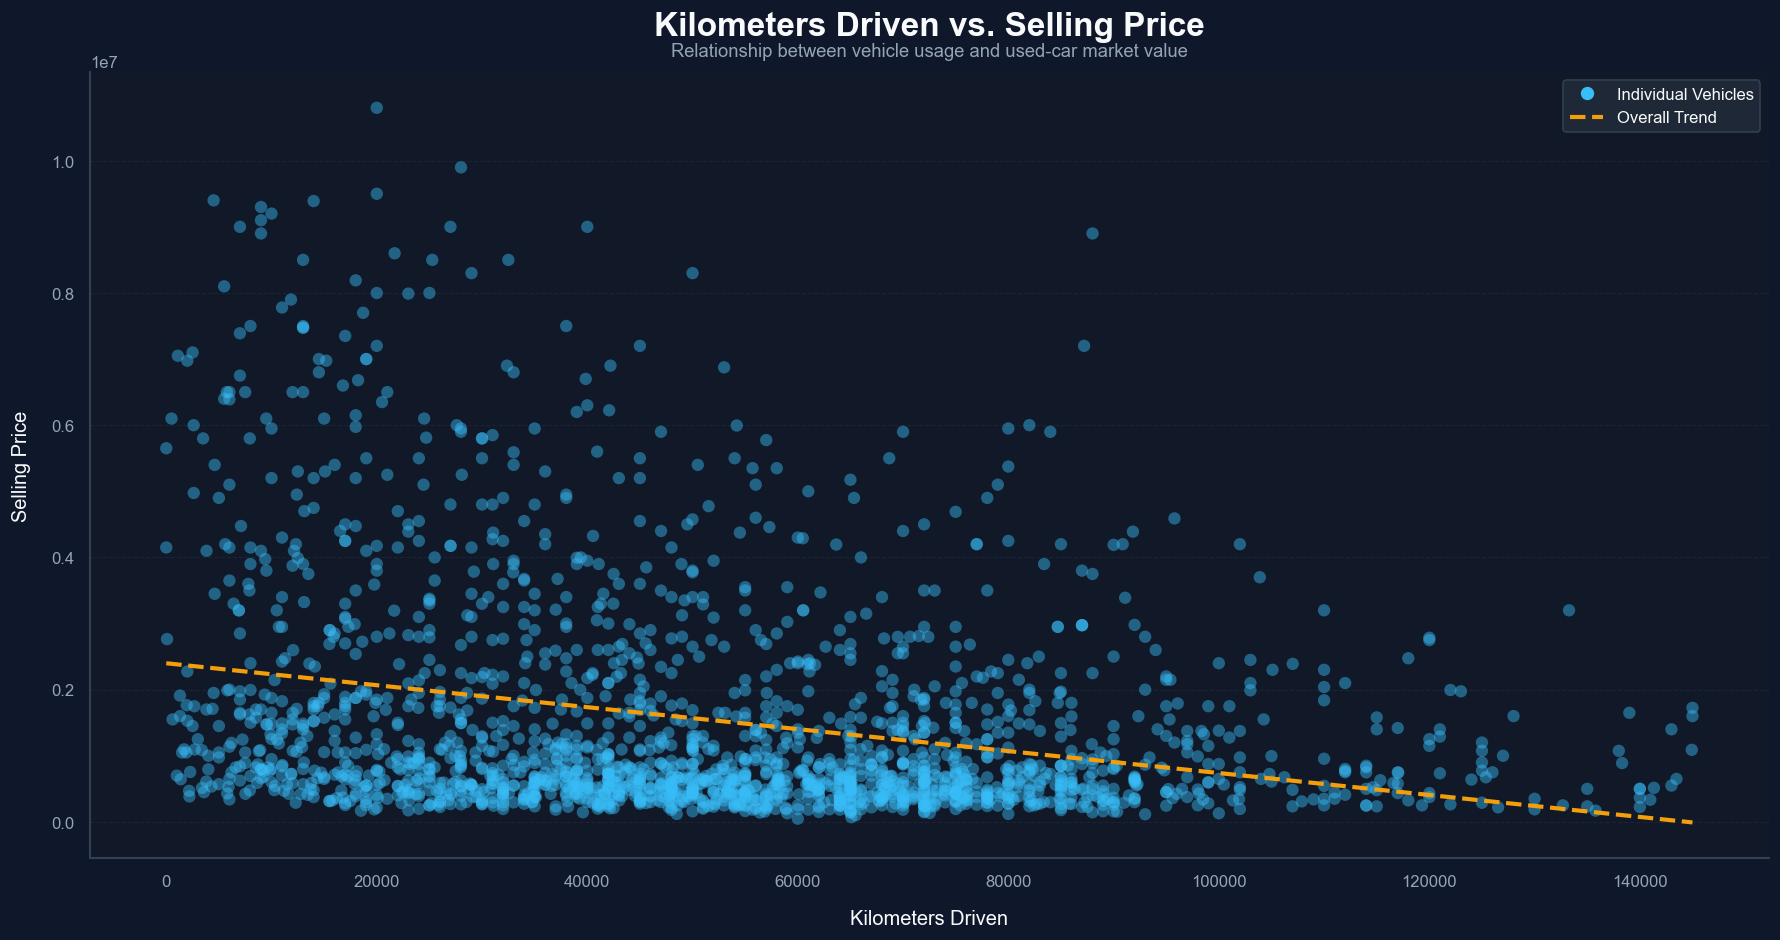

Chart saved successfully: ../images/kilometer_vs_price.png
Original records       : 2,059
Visualization records  : 2,016
Kilometer 99th percentile: 147,150
Price 99th percentile    : 10,843,000


In [32]:
# ============================================================
# KILOMETERS DRIVEN VS SELLING PRICE
# ============================================================

fig, ax = plt.subplots(figsize=(15, 8))

# ------------------------------------------------------------
# Background
# ------------------------------------------------------------

fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["axes"])

# ------------------------------------------------------------
# Prepare Visualization Data
# ------------------------------------------------------------

plot_df = df[
    (df["Kilometer"].notna()) &
    (df["Price"].notna()) &
    (df["Kilometer"] > 0) &
    (df["Price"] > 0)
].copy()

# Remove extreme outliers only for visualization
# Keep original df unchanged

km_upper = plot_df["Kilometer"].quantile(0.99)
price_upper = plot_df["Price"].quantile(0.99)

plot_df = plot_df[
    (plot_df["Kilometer"] <= km_upper) &
    (plot_df["Price"] <= price_upper)
].copy()

# ------------------------------------------------------------
# Scatter Plot
# ------------------------------------------------------------

sns.scatterplot(
    data=plot_df,
    x="Kilometer",
    y="Price",
    color=CAR_COLORS["primary"],
    alpha=0.45,
    s=55,
    edgecolor="none",
    ax=ax
)

# ------------------------------------------------------------
# Trend Line
# ------------------------------------------------------------

sns.regplot(
    data=plot_df,
    x="Kilometer",
    y="Price",
    scatter=False,
    ci=None,
    color=CAR_COLORS["warning"],
    line_kws={
        "linewidth": 2.5,
        "linestyle": "--"
    },
    ax=ax
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Kilometers Driven vs. Selling Price",
    fontsize=20,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=22
)

# ------------------------------------------------------------
# Subtitle
# ------------------------------------------------------------

ax.text(
    0.5,
    1.015,
    "Relationship between vehicle usage and used-car market value",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=CAR_COLORS["muted"]
)

# ------------------------------------------------------------
# Axis Labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Kilometers Driven",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Selling Price",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

# ------------------------------------------------------------
# Tick Formatting
# ------------------------------------------------------------

ax.tick_params(
    axis="both",
    colors=CAR_COLORS["muted"],
    labelsize=10
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(
    axis="y",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.7,
    alpha=0.30
)

ax.grid(
    axis="x",
    visible=False
)

# ------------------------------------------------------------
# Axis Spines
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(CAR_COLORS["grid"])
ax.spines["bottom"].set_color(CAR_COLORS["grid"])

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=CAR_COLORS["primary"],
        markeredgecolor="none",
        markersize=8,
        label="Individual Vehicles"
    ),

    Line2D(
        [0],
        [0],
        color=CAR_COLORS["warning"],
        linewidth=2.5,
        linestyle="--",
        label="Overall Trend"
    )
]

legend = ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    fontsize=10
)

legend.get_frame().set_facecolor("#1F2937")
legend.get_frame().set_edgecolor(CAR_COLORS["grid"])

for text in legend.get_texts():
    text.set_color(CAR_COLORS["text"])

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save Chart
# ------------------------------------------------------------

output_path = "../images/kilometer_vs_price.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")
print(f"Original records       : {len(df):,}")
print(f"Visualization records  : {len(plot_df):,}")
print(f"Kilometer 99th percentile: {km_upper:,.0f}")
print(f"Price 99th percentile    : {price_upper:,.0f}")

### 🔎 Key Observation

The scatter plot shows the relationship between kilometers driven and selling
price. The overall trend line indicates the general direction of this
relationship, while the wide distribution of points shows that mileage alone
does not determine a car's selling price.

Other factors such as **brand, car age, fuel type, transmission, engine
capacity, and vehicle condition** can also have a significant influence on
market value.

**Machine Learning Insight:** Kilometer driven is therefore an important
predictive feature, but it should be combined with other vehicle attributes
rather than being used independently for price prediction.

### 7.5 Selling Price Distribution by Transmission

Transmission type can influence the resale value of a used vehicle because
manual and automatic vehicles may differ in buyer demand, driving convenience,
maintenance cost, and market positioning.

The box plot compares the distribution of selling prices across transmission
types. The median line represents the typical selling price, while the box
shows the middle 50% of observations.

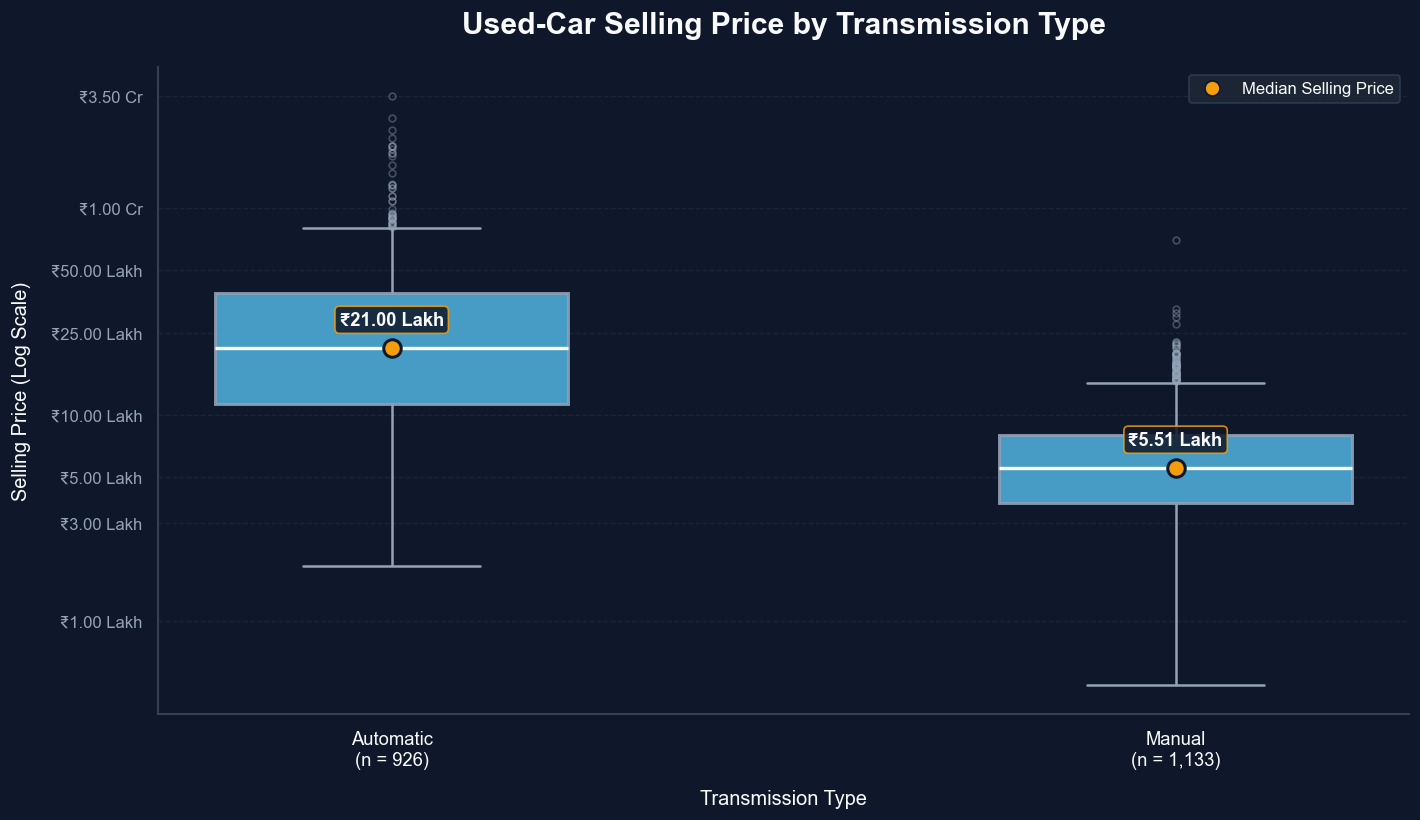

In [33]:
# ============================================================
# DATA PREPARATION & CLEANING
# ============================================================

required_columns = ["Transmission", "Price"]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

transmission_data = df[required_columns].dropna().copy()
transmission_data["Transmission"] = (
    transmission_data["Transmission"].astype(str).str.strip().str.title()
)
transmission_data["Price"] = pd.to_numeric(
    transmission_data["Price"], errors="coerce"
)
transmission_data = transmission_data[transmission_data["Price"] > 0].dropna(
    subset=["Price"]
)

# Order categories by median price
transmission_order = (
    transmission_data.groupby("Transmission")["Price"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

transmission_counts = transmission_data["Transmission"].value_counts()
median_prices = transmission_data.groupby("Transmission")["Price"].median()

# Create clean X-axis category labels including sample count
x_labels = [
    f"{trans}\n(n = {transmission_counts[trans]:,})"
    for trans in transmission_order
]

# ============================================================
# PLOT SETUP
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["background"])

# ============================================================
# BOX PLOT (WITH LOG SCALE)
# ============================================================

sns.boxplot(
    data=transmission_data,
    x="Transmission",
    y="Price",
    order=transmission_order,
    width=0.45,
    linewidth=1.8,
    fliersize=4,
    color=CAR_COLORS["primary"],
    boxprops=dict(alpha=0.85, edgecolor=CAR_COLORS.get("border", "#94A3B8")),
    medianprops=dict(color="#FFFFFF", linewidth=2),
    whiskerprops=dict(color=CAR_COLORS["muted"], linewidth=1.5),
    capprops=dict(color=CAR_COLORS["muted"], linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor=CAR_COLORS["muted"],
        alpha=0.4,
    ),
    ax=ax,
)

# Use logarithmic scale to clearly reveal box distributions
ax.set_yscale("log")

# ============================================================
# MEDIAN MARKERS & ANNOTATIONS
# ============================================================


def format_inr_short(val):
    """Format numeric values into readable Indian denominations."""
    if val >= 10_000_000:
        return f"₹{val/10_000_000:.2f} Cr"
    elif val >= 100_000:
        return f"₹{val/100_000:.2f} Lakh"
    return f"₹{val:,.0f}"


for index, transmission in enumerate(transmission_order):
    median_val = median_prices.loc[transmission]

    # Median dot
    ax.scatter(
        index,
        median_val,
        s=110,
        color=CAR_COLORS["warning"],
        edgecolor=CAR_COLORS["background"],
        linewidth=1.8,
        zorder=6,
    )

    # Offset annotation text
    ax.annotate(
        format_inr_short(median_val),
        xy=(index, median_val),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color=CAR_COLORS["text"],
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc=CAR_COLORS["background"],
            ec=CAR_COLORS["warning"],
            lw=1,
            alpha=0.85,
        ),
        zorder=7,
    )

# ============================================================
# AXES & FORMATTING
# ============================================================

ax.set_title(
    "Used-Car Selling Price by Transmission Type",
    fontsize=18,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=20,
)

ax.set_xlabel(
    "Transmission Type",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12,
)

ax.set_ylabel(
    "Selling Price (Log Scale)",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12,
)

# Apply dynamic Lakh/Crore tick formatting
y_ticks = [100_000, 300_000, 500_000, 1_000_000, 2_500_000, 5_000_000, 10_000_000, 35_000_000]
ax.set_yticks(y_ticks)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: format_inr_short(y)))

ax.set_xticklabels(x_labels, fontsize=11, color=CAR_COLORS["text"])
ax.tick_params(axis="y", colors=CAR_COLORS["muted"], labelsize=10)

# Grid styling
ax.grid(
    axis="y",
    which="major",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.35,
)
ax.grid(axis="x", visible=False)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(CAR_COLORS["grid"])
ax.spines["bottom"].set_color(CAR_COLORS["grid"])

# ============================================================
# LEGEND & OUTPUT
# ============================================================

median_legend = Line2D(
    [0],
    [0],
    marker="o",
    color="none",
    markerfacecolor=CAR_COLORS["warning"],
    markeredgecolor=CAR_COLORS["background"],
    markersize=9,
    label="Median Selling Price",
)

legend = ax.legend(
    handles=[median_legend],
    loc="upper right",
    frameon=True,
    facecolor="#1F2937",
    edgecolor=CAR_COLORS["grid"],
    fontsize=10,
)
for text in legend.get_texts():
    text.set_color(CAR_COLORS["text"])

plt.tight_layout()
output_path = f"{IMAGE_PATH}price_by_transmission.png"
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"],
)
plt.show()

### 🔎 Key Observation

**Automatic** vehicles have the highest median selling price at approximately **₹2,100,000**, while **Manual** vehicles have the lowest median selling price at approximately **₹551,000**.

The box plot also highlights the spread and presence of potential price outliers within each transmission category.

### 7.6 Top Vehicle Brands

Brand reputation and market demand can strongly influence used-car prices.

We identify the most frequently represented vehicle brands in the dataset.

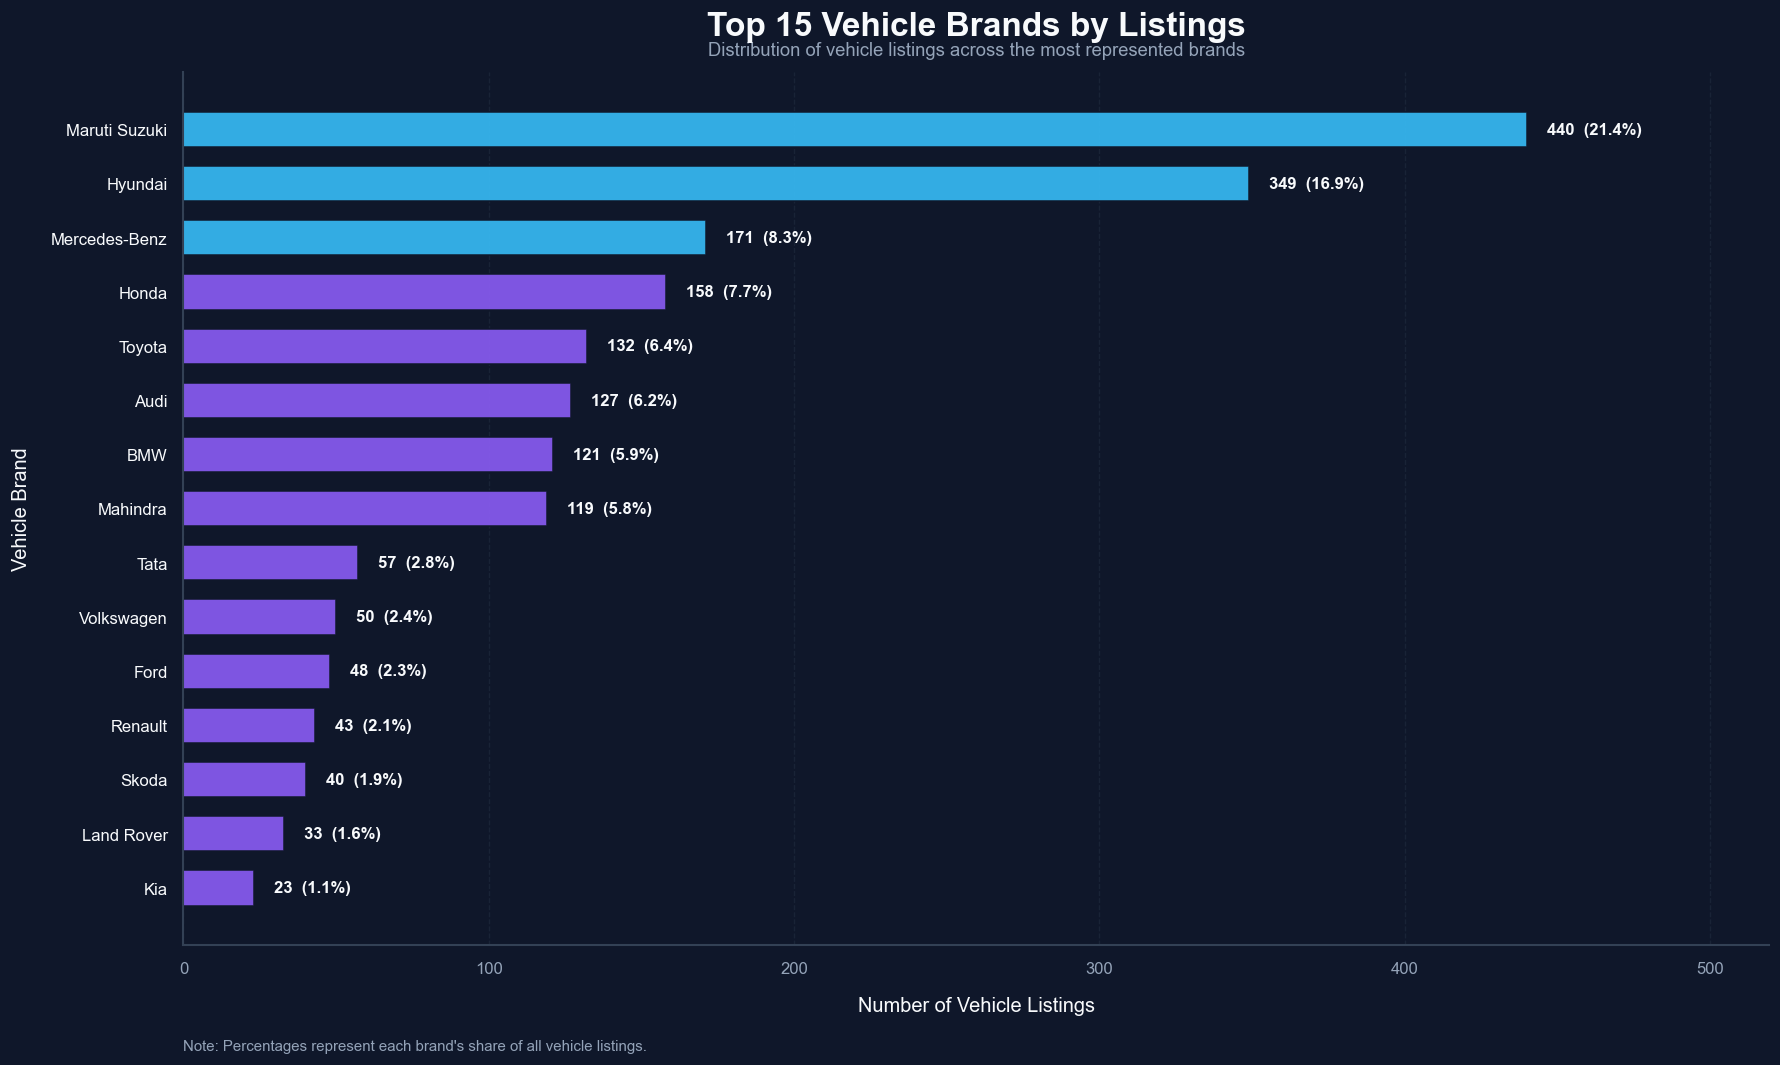

Chart saved successfully: ../images/top_vehicle_brands.png


In [34]:
# ============================================================
# TOP 15 VEHICLE BRANDS BY NUMBER OF LISTINGS
# ============================================================

# Calculate brand counts
top_brands = (
    df["Brand"]
    .dropna()
    .astype(str)
    .str.strip()
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

# Total listings used for percentage calculation
total_listings = len(df)

# Percentage contribution
brand_percentage = (
    top_brands / total_listings * 100
)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(15, 9))

# Explicit background
fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["background"])

# ============================================================
# BAR COLORS
# ============================================================

bar_colors = []

for i in range(len(top_brands)):

    # Highlight the three highest-volume brands
    if i >= len(top_brands) - 3:
        bar_colors.append(CAR_COLORS["primary"])
    else:
        bar_colors.append(CAR_COLORS["secondary"])

# ============================================================
# MAIN BAR CHART
# ============================================================

bars = ax.barh(
    top_brands.index,
    top_brands.values,
    color=bar_colors,
    height=0.65,
    alpha=0.90,
    edgecolor=CAR_COLORS["background"],
    linewidth=1
)

# ============================================================
# VALUE LABELS
# ============================================================

max_value = top_brands.max()

for bar, count, percentage in zip(
    bars,
    top_brands.values,
    brand_percentage.values
):

    ax.text(
        bar.get_width() + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=CAR_COLORS["text"]
    )

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Top 15 Vehicle Brands by Listings",
    fontsize=20,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=22
)

# ============================================================
# SUBTITLE
# ============================================================

ax.text(
    0.5,
    1.015,
    "Distribution of vehicle listings across the most represented brands",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=CAR_COLORS["muted"]
)

# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Number of Vehicle Listings",
    fontsize=12,
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Vehicle Brand",
    fontsize=12,
    color=CAR_COLORS["text"],
    labelpad=12
)

# ============================================================
# TICK FORMATTING
# ============================================================

ax.tick_params(
    axis="x",
    colors=CAR_COLORS["muted"],
    labelsize=10
)

ax.tick_params(
    axis="y",
    colors=CAR_COLORS["text"],
    labelsize=10
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="x",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.30
)

ax.grid(
    axis="y",
    visible=False
)

# ============================================================
# REMOVE UNNECESSARY SPINES
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(CAR_COLORS["grid"])
ax.spines["bottom"].set_color(CAR_COLORS["grid"])

# ============================================================
# X-AXIS RANGE
# ============================================================

ax.set_xlim(
    0,
    max_value * 1.18
)

# ============================================================
# FOOTNOTE
# ============================================================

ax.text(
    0,
    -0.12,
    "Note: Percentages represent each brand's share of all vehicle listings.",
    transform=ax.transAxes,
    fontsize=9,
    color=CAR_COLORS["muted"]
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE IMAGE
# ============================================================

output_path = f"{IMAGE_PATH}top_vehicle_brands.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔎 Key Observation

The dataset is concentrated among a relatively small number of vehicle brands.
The most frequently listed brands account for a substantial share of the total
vehicle listings, indicating that the dataset is not evenly distributed across
manufacturers.

This concentration is important for the prediction model because brand can
capture differences in market demand, resale value, reliability, and pricing
behavior.

The top three brands are highlighted in the visualization to make the highest
listing volumes immediately identifiable.

### 7.7 Numerical Feature Correlation

Correlation analysis helps identify relationships between numerical variables.

A correlation coefficient close to:

- +1 indicates a strong positive relationship
- 0 indicates little linear relationship
- -1 indicates a strong negative relationship

The heatmap provides an initial understanding of which numerical features may
be useful for predicting vehicle price.

Numerical Features:
['Price', 'Year', 'Kilometer', 'Engine', 'Max Power', 'Max Torque', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'Car Age']


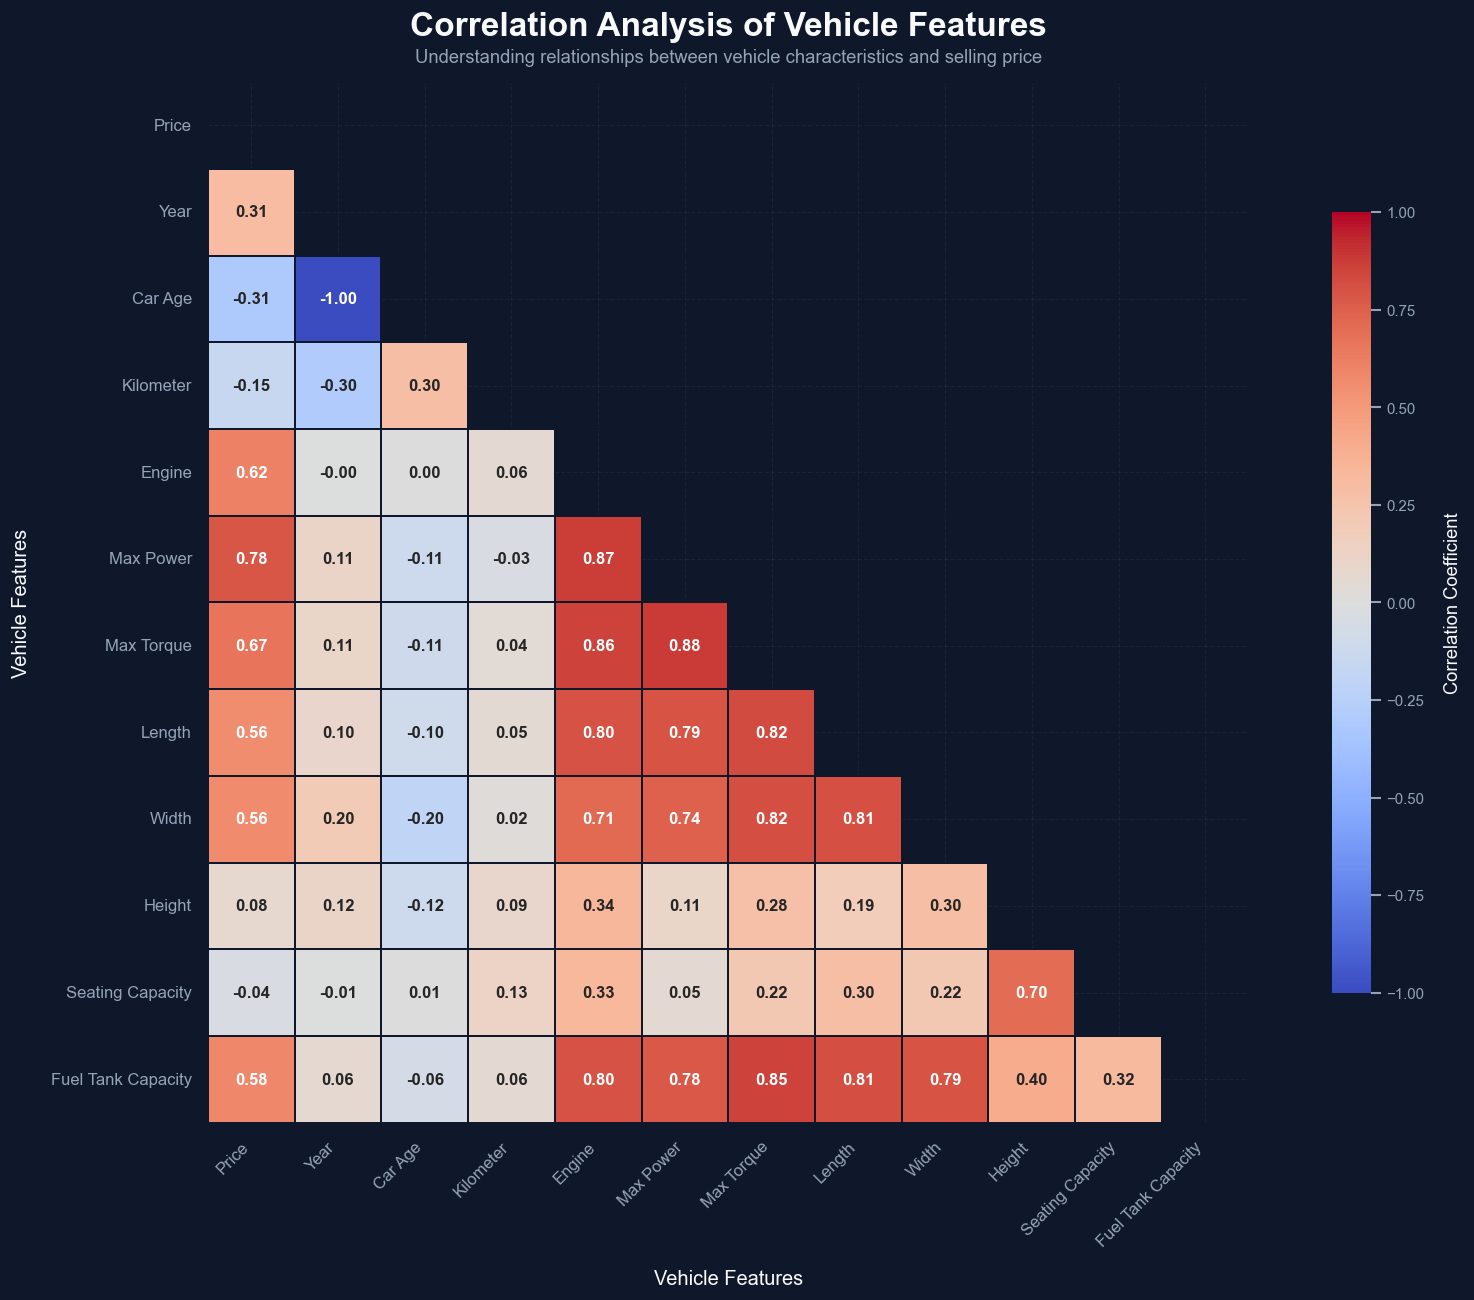

Correlation heatmap saved successfully: ../images/correlation_heatmap.png


In [35]:
# ------------------------------------------------------------
# 1. Select numerical columns
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Features:")
print(numeric_columns)


# ------------------------------------------------------------
# 2. Calculate correlation matrix
# ------------------------------------------------------------

correlation_matrix = df[numeric_columns].corr()


# ------------------------------------------------------------
# 3. Select important numerical features for visualization
# ------------------------------------------------------------
# Keeping the main heatmap focused improves readability.

preferred_features = [
    "Price",
    "Year",
    "Car Age",
    "Kilometer",
    "Engine",
    "Max Power",
    "Max Torque",
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity"
]

# Keep only columns that actually exist in the dataset
heatmap_features = [
    column
    for column in preferred_features
    if column in correlation_matrix.columns
]

correlation_subset = correlation_matrix.loc[
    heatmap_features,
    heatmap_features
]


# ------------------------------------------------------------
# 4. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 11))

fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["background"])


# ------------------------------------------------------------
# 5. Create mask for upper triangle
# ------------------------------------------------------------
# This avoids displaying duplicate information.

mask = np.triu(
    np.ones_like(correlation_subset, dtype=bool)
)


# ------------------------------------------------------------
# 6. Create heatmap
# ------------------------------------------------------------

sns.heatmap(
    correlation_subset,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor=CAR_COLORS["background"],
    square=True,
    cbar_kws={
        "label": "Correlation Coefficient",
        "shrink": 0.75
    },
    annot_kws={
        "fontsize": 10,
        "fontweight": "bold"
    },
    ax=ax
)


# ------------------------------------------------------------
# 7. Title
# ------------------------------------------------------------

ax.set_title(
    "Correlation Analysis of Vehicle Features",
    fontsize=20,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=28
)


# ------------------------------------------------------------
# 8. Subtitle
# ------------------------------------------------------------

ax.text(
    0.5,
    1.015,
    "Understanding relationships between vehicle characteristics and selling price",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=CAR_COLORS["muted"]
)


# ------------------------------------------------------------
# 9. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Vehicle Features",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Vehicle Features",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)


# ------------------------------------------------------------
# 10. Tick formatting
# ------------------------------------------------------------

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    color=CAR_COLORS["muted"],
    fontsize=10
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0,
    color=CAR_COLORS["muted"],
    fontsize=10
)


# ------------------------------------------------------------
# 11. Colorbar formatting
# ------------------------------------------------------------

colorbar = ax.collections[0].colorbar

colorbar.set_label(
    "Correlation Coefficient",
    color=CAR_COLORS["text"],
    fontsize=11,
    labelpad=12
)

colorbar.ax.tick_params(
    colors=CAR_COLORS["muted"],
    labelsize=9
)

colorbar.outline.set_edgecolor(
    CAR_COLORS["grid"]
)


# ------------------------------------------------------------
# 12. Remove unnecessary borders
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(
    CAR_COLORS["grid"]
)

ax.spines["bottom"].set_color(
    CAR_COLORS["grid"]
)


# ------------------------------------------------------------
# 13. Layout
# ------------------------------------------------------------

plt.tight_layout()


# ------------------------------------------------------------
# 14. Save chart
# ------------------------------------------------------------

output_path = (
    f"{IMAGE_PATH}correlation_heatmap.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"]
)

plt.show()


# ------------------------------------------------------------
# 15. Confirmation
# ------------------------------------------------------------

print(
    f"Correlation heatmap saved successfully: {output_path}"
)

### 🔎 Key Observation
- Car Age and Kilometers Driven may show a negative relationship with Price, indicating lower resale value for  older and heavily used vehicles.
- Engine, Max Power, and Year may have positive relationships with Price.
- Year and Car Age are strongly related because Car Age is derived from Year.
- Correlation shows association, not causation; model performance will provide stronger evidence of predictive value.

### 7.8 Features Most Correlated with Price

To identify potentially influential numerical features, we calculate the
correlation of numerical variables specifically with the target variable.

In [36]:
price_correlations = (
    correlation_matrix["Price"]
    .sort_values(ascending=False)
)

price_correlations

Price                 1.000000
Max Power             0.781419
Max Torque            0.671290
Engine                0.615328
Fuel Tank Capacity    0.584631
Width                 0.563996
Length                0.556741
Year                  0.311400
Height                0.075080
Seating Capacity     -0.038524
Kilometer            -0.150825
Car Age              -0.311400
Name: Price, dtype: float64

## 8. Data Quality Validation

Before moving to machine learning, we perform a final inspection of:

- Missing values
- Duplicate records
- Data types
- Target variable
- Engineered features

This validation helps ensure that the modelling stage starts from a reliable
dataset.

In [37]:
print("=" * 60)
print("FINAL DATA QUALITY CHECK")
print("=" * 60)

print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nData types:")
print(df.dtypes)

FINAL DATA QUALITY CHECK

Rows    : 2,059
Columns : 22

Duplicate rows: 0

Missing values:
Drivetrain            136
Fuel Tank Capacity    113
Engine                 80
Max Torque             80
Max Power              80
Seating Capacity       64
Height                 64
Width                  64
Length                 64
Model                   0
Car Age                 0
Make                    0
Seller Type             0
Owner                   0
Color                   0
dtype: int64

Data types:
Make                  string[python]
Model                 string[python]
Price                          int64
Year                           int64
Kilometer                      int64
Fuel Type             string[python]
Transmission          string[python]
Location              string[python]
Color                 string[python]
Owner                 string[python]
Seller Type           string[python]
Engine                       float64
Max Power                    float64
Max Torque  

In [38]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Car Age,Brand
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,87.0,109.0000,Fwd,3990.0,1680.0,1505.0,5.0,35.0,9,Honda
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,74.0,190.0000,Fwd,3995.0,1695.0,1555.0,5.0,42.0,12,Maruti Suzuki
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,79.0,112.7619,Fwd,3585.0,1595.0,1550.0,5.0,35.0,15,Hyundai
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,82.0,113.0000,Fwd,3995.0,1745.0,1510.0,5.0,37.0,7,Toyota
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,148.0,343.0000,Rwd,4735.0,1830.0,1795.0,7.0,55.0,8,Toyota


# 9. Machine Learning Preparation

After completing data cleaning, feature engineering, and exploratory data
analysis, the dataset is prepared for supervised machine learning.

The objective is to predict the selling price of a used car using the available
vehicle characteristics.

The machine learning workflow consists of:

1. Feature and target selection
2. Data type validation
3. Numerical and categorical feature identification
4. Missing-value handling
5. Categorical encoding
6. Train-test splitting
7. Model training
8. Model evaluation
9. Model comparison
10. Feature importance analysis
11. Final model persistence

In [39]:
# ============================================================
# 9.1 PRE-MODELING DATA VALIDATION
# ============================================================

print("=" * 65)
print("PRE-MODELING DATA VALIDATION")
print("=" * 65)

print(f"\nDataset shape : {df.shape}")
print(f"Target column : {TARGET_COLUMN}")

print("\nTarget missing values:")
print(df[TARGET_COLUMN].isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

PRE-MODELING DATA VALIDATION

Dataset shape : (2059, 22)
Target column : Price

Target missing values:
0

Duplicate rows:
0


### 9.1 Target Variable Validation

The target variable must contain valid numerical values because the model learns
to predict this value.

Records with missing or invalid selling prices cannot contribute to supervised
learning and are therefore removed before model training.

In [40]:
# ============================================================
# TARGET VARIABLE CLEANING
# ============================================================

df[TARGET_COLUMN] = pd.to_numeric(
    df[TARGET_COLUMN],
    errors="coerce"
)

before_rows = len(df)

df = df.dropna(
    subset=[TARGET_COLUMN]
).reset_index(drop=True)

after_rows = len(df)

print(f"Rows before target validation : {before_rows:,}")
print(f"Rows after target validation  : {after_rows:,}")
print(f"Rows removed                  : {before_rows - after_rows:,}")

Rows before target validation : 2,059
Rows after target validation  : 2,059
Rows removed                  : 0


# 10. Feature and Target Selection

The machine learning problem is formulated as a supervised regression task.

### Target

**Price** is the dependent variable that the model must predict.

### Features

All relevant remaining vehicle characteristics are considered as independent
variables.

The target variable is separated from the feature matrix before preprocessing.

In [41]:
# ============================================================
# 10.1 FEATURE AND TARGET SELECTION
# ============================================================

X = df.drop(columns=[TARGET_COLUMN]).copy()

y = df[TARGET_COLUMN].copy()

print("Feature matrix shape :", X.shape)
print("Target vector shape  :", y.shape)

print("\nTarget statistics:")
print(y.describe())

Feature matrix shape : (2059, 21)
Target vector shape  : (2059,)

Target statistics:
count    2.059000e+03
mean     1.702992e+06
std      2.419881e+06
min      4.900000e+04
25%      4.849990e+05
50%      8.250000e+05
75%      1.925000e+06
max      3.500000e+07
Name: Price, dtype: float64


# 11. Data Type Standardization

Before creating the preprocessing pipeline, feature data types are validated.

Numerical variables are converted to numerical representations, while
categorical variables are converted to standard object/string-compatible
values.

Missing categorical values are represented as `NaN`, allowing Scikit-learn's
`SimpleImputer` to handle them safely.

This prevents Pandas nullable `pd.NA` values from causing compatibility issues
during machine learning preprocessing.

In [42]:
# ============================================================
# 11.1 DATA TYPE STANDARDIZATION
# ============================================================

# Identify columns based on their current data types
categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()

# Convert categorical columns to object dtype.
# Replace Pandas pd.NA with NumPy NaN.
for column in categorical_features:
    X[column] = X[column].astype(object)
    X[column] = X[column].where(
        X[column].notna(),
        np.nan
    )

# Convert numerical columns safely to numeric
for column in numerical_features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

print("=" * 65)
print("FEATURE TYPE SUMMARY")
print("=" * 65)

print(f"\nNumerical features   : {len(numerical_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

FEATURE TYPE SUMMARY

Numerical features   : 11
Categorical features : 10

Numerical Features:
['Year', 'Kilometer', 'Engine', 'Max Power', 'Max Torque', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'Car Age']

Categorical Features:
['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Drivetrain', 'Brand']


# 12. Feature Overview

The feature matrix contains both numerical and categorical variables.

Numerical features can be passed through numerical preprocessing, while
categorical variables require encoding before they can be used by the
regression algorithms.

In [43]:
# ============================================================
# 12.1 FEATURE SUMMARY
# ============================================================

feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values,
    "Missing Values": X.isna().sum().values,
    "Unique Values": X.nunique(dropna=True).values
})

feature_summary

,Feature,Data Type,Missing Values,Unique Values
0,Make,object,0,33
1,Model,object,0,1050
2,Year,int64,0,22
3,Kilometer,int64,0,847
4,Fuel Type,object,0,9
5,Transmission,object,0,2
6,Location,object,0,77
7,Color,object,0,17
8,Owner,object,0,6
9,Seller Type,object,0,3


# 13. Data Preprocessing Pipeline

Machine learning models require numerical input and cannot directly process
raw categorical text.

A Scikit-learn `ColumnTransformer` is used to apply different transformations
to numerical and categorical features.

### Numerical Features

Missing numerical values are replaced using the median.

### Categorical Features

Missing categorical values are replaced using the most frequent category and
then transformed using One-Hot Encoding.

### Why use a Pipeline?

Using a pipeline ensures that preprocessing is learned only from the training
data and then consistently applied to unseen test data.

This helps prevent data leakage and makes the workflow reproducible.

In [44]:
# ============================================================
# 13.1 PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# 14. Train-Test Split

The dataset is divided into two subsets:

- **80% Training Data** — used to learn patterns from historical observations
- **20% Testing Data** — used to evaluate performance on unseen observations

A fixed random state is used to make the experiment reproducible.

In [45]:
# ============================================================
# 14.1 TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("=" * 65)
print("TRAIN-TEST SPLIT")
print("=" * 65)

print(f"\nTraining features : {X_train.shape}")
print(f"Testing features  : {X_test.shape}")

print(f"\nTraining target   : {y_train.shape}")
print(f"Testing target    : {y_test.shape}")

print(
    f"\nTraining percentage : {len(X_train) / len(X) * 100:.1f}%"
)

print(
    f"Testing percentage  : {len(X_test) / len(X) * 100:.1f}%"
)

TRAIN-TEST SPLIT

Training features : (1647, 21)
Testing features  : (412, 21)

Training target   : (1647,)
Testing target    : (412,)

Training percentage : 80.0%
Testing percentage  : 20.0%


# 15. Linear Regression — Baseline Model

Linear Regression is used as the baseline regression model.

The model attempts to learn a linear relationship between the input features
and vehicle selling price.

Although it is relatively simple, Linear Regression provides an important
baseline against which more complex models can be compared.

In [46]:
# ============================================================
# 15.1 LINEAR REGRESSION
# ============================================================

linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_pipeline.fit(
    X_train,
    y_train
)

linear_predictions = linear_pipeline.predict(
    X_test
)

print("Linear Regression training completed successfully.")

Linear Regression training completed successfully.


# 16. Random Forest Regressor

Random Forest is an ensemble machine learning algorithm that combines multiple
decision trees.

Unlike Linear Regression, Random Forest can model nonlinear relationships and
complex interactions between vehicle characteristics.

The model is therefore evaluated as the second regression approach.

In [47]:
# ============================================================
# 16.1 RANDOM FOREST REGRESSOR
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_predictions = rf_pipeline.predict(
    X_test
)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


# 17. Model Evaluation

The models are evaluated using three regression metrics.

### MAE — Mean Absolute Error

MAE represents the average absolute difference between actual and predicted
prices.

**Lower MAE is better.**

### RMSE — Root Mean Squared Error

RMSE gives greater importance to large prediction errors.

**Lower RMSE is better.**

### R² Score

R² measures the proportion of variation in the target variable explained by
the model.

**Higher R² is better, with 1.0 representing a perfect score.**

In [48]:
# ============================================================
# 17.1 MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_regression_model(actual, predicted):
    """
    Calculate standard regression evaluation metrics.
    """

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

# 18. Model Comparison

Both models are evaluated on the same unseen test dataset.

The comparison considers:

- MAE
- RMSE
- R² Score

No model is declared superior before examining the actual evaluation results.

In [49]:
# ============================================================
# 18.1 EVALUATE BOTH MODELS
# ============================================================

linear_metrics = evaluate_regression_model(
    y_test,
    linear_predictions
)

rf_metrics = evaluate_regression_model(
    y_test,
    rf_predictions
)

results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **linear_metrics
    },
    {
        "Model": "Random Forest Regressor",
        **rf_metrics
    }
])

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,712092.152115,1.369080e+06,0.731706
1,Random Forest Regressor,297043.067284,1.168553e+06,0.804543


In [50]:
# ============================================================
# 18.2 FORMATTED MODEL COMPARISON
# ============================================================

results_display = results.copy()

results_display["MAE"] = results_display["MAE"].round(2)
results_display["RMSE"] = results_display["RMSE"].round(2)
results_display["R2 Score"] = results_display["R2 Score"].round(4)

results_display

,Model,MAE,RMSE,R2 Score
0,Linear Regression,712092.15,1369080.21,0.7317
1,Random Forest Regressor,297043.07,1168553.45,0.8045


## 18.1 Best Model Selection

The final model is selected using R² as the primary ranking metric because it
measures how much variation in selling price is explained by the model.

MAE and RMSE are also considered to verify the model's absolute prediction
error.

In [51]:
# ============================================================
# 18.3 BEST MODEL SELECTION
# ============================================================

best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print(f"Best-performing model based on R²: {best_model_name}")

Best-performing model based on R²: Random Forest Regressor


# 19. Actual vs Predicted Prices

A useful way to visually evaluate regression performance is to compare actual
selling prices with model predictions.

Ideally, predictions should remain close to the diagonal relationship between
actual and predicted values.

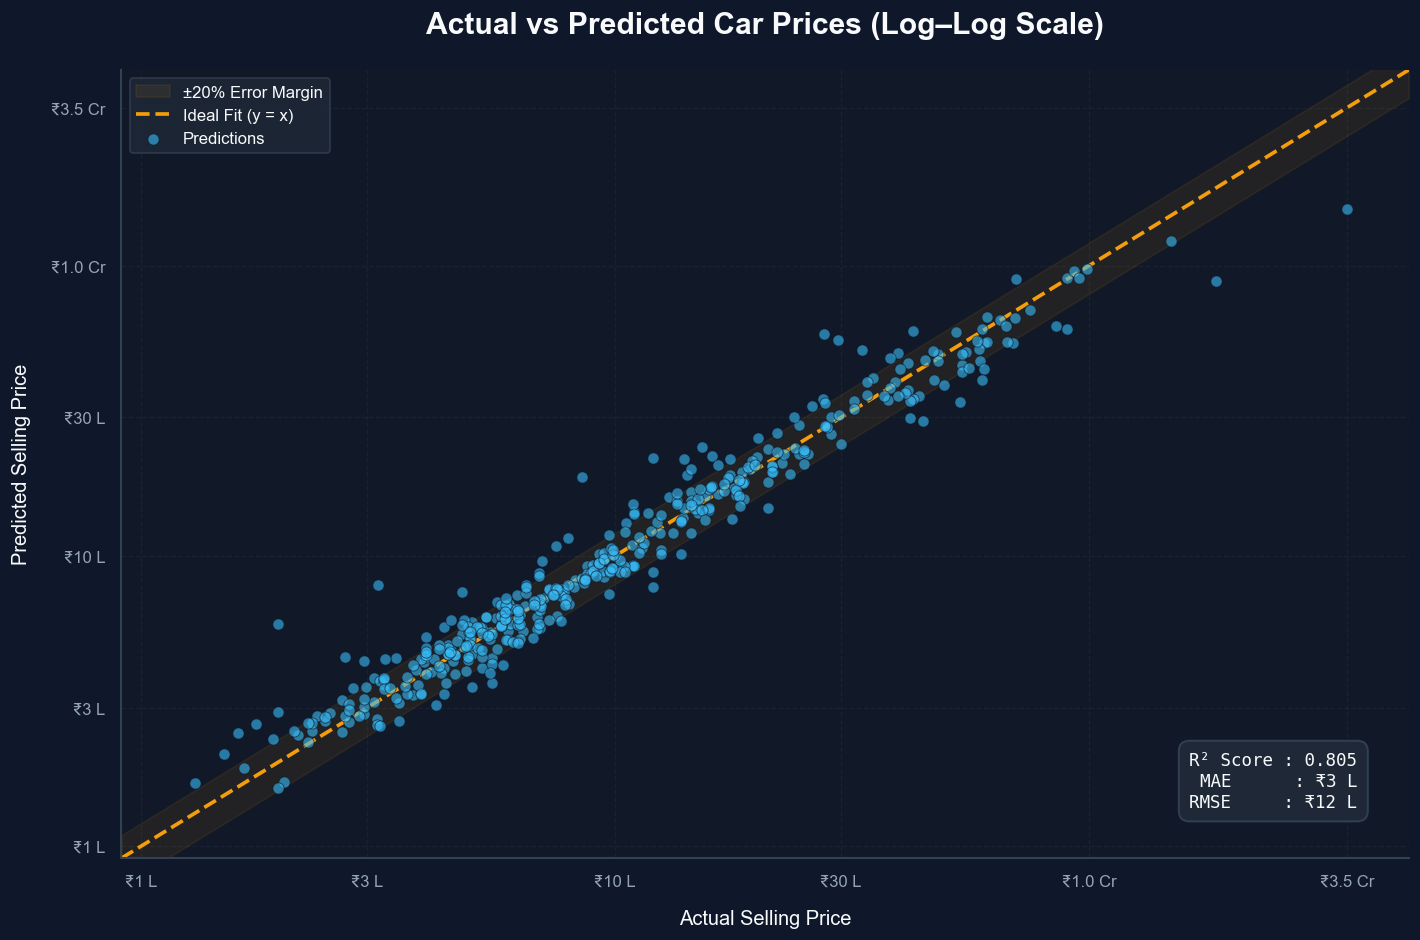

Chart saved successfully: ../images/actual_vs_predicted.png


In [52]:
# ------------------------------------------------------------
# Calculate evaluation metrics
# ------------------------------------------------------------

actual = np.asarray(y_test, dtype=float)
predicted = np.asarray(rf_predictions, dtype=float)

# Clip predicted values slightly above 0 for safe log plotting
actual_safe = np.maximum(actual, 1)
predicted_safe = np.maximum(predicted, 1)

actual_pred_mae = mean_absolute_error(actual, predicted)
actual_pred_rmse = np.sqrt(mean_squared_error(actual, predicted))
actual_pred_r2 = r2_score(actual, predicted)

# ------------------------------------------------------------
# Determine logarithmic range
# ------------------------------------------------------------

min_val = min(actual_safe.min(), predicted_safe.min())
max_val = max(actual_safe.max(), predicted_safe.max())

# Add margin on log space
plot_min = min_val * 0.7
plot_max = max_val * 1.35

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS.get("axes", CAR_COLORS["background"]))

# Set both axes to Logarithmic scale
ax.set_xscale("log")
ax.set_yscale("log")

# ------------------------------------------------------------
# Error tolerance bands (±20% region) & Perfect line
# ------------------------------------------------------------

line_pts = np.logspace(np.log10(plot_min), np.log10(plot_max), 200)

# ±20% error tolerance band
ax.fill_between(
    line_pts,
    line_pts * 0.8,
    line_pts * 1.2,
    color=CAR_COLORS["warning"],
    alpha=0.08,
    label="±20% Error Margin",
    zorder=1
)

# Perfect prediction line (y = x)
ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color=CAR_COLORS["warning"],
    linewidth=2.2,
    linestyle="--",
    label="Ideal Fit (y = x)",
    zorder=2
)

# ------------------------------------------------------------
# Actual vs Predicted scatter points
# ------------------------------------------------------------

ax.scatter(
    actual_safe,
    predicted_safe,
    s=45,
    alpha=0.60,
    color=CAR_COLORS["primary"],
    edgecolors=CAR_COLORS["background"],
    linewidths=0.6,
    label="Predictions",
    zorder=3
)

# ------------------------------------------------------------
# Axis limits & Indian currency formatter
# ------------------------------------------------------------

ax.set_xlim(plot_min, plot_max)
ax.set_ylim(plot_min, plot_max)

def format_inr(val, pos=None):
    if val >= 10_000_000:
        return f"₹{val/10_000_000:.1f} Cr"
    elif val >= 100_000:
        return f"₹{val/100_000:.0f} L"
    elif val >= 1_000:
        return f"₹{val/1_000:.0f}k"
    return f"₹{val:,.0f}"

ticks = [50_000, 100_000, 300_000, 1_000_000, 3_000_000, 10_000_000, 35_000_000]
ticks = [t for t in ticks if plot_min <= t <= plot_max]

ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_inr))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_inr))

# ------------------------------------------------------------
# Title & Labels
# ------------------------------------------------------------

ax.set_title(
    "Actual vs Predicted Car Prices (Log–Log Scale)",
    fontsize=18,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=22
)

ax.set_xlabel(
    "Actual Selling Price",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Predicted Selling Price",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.tick_params(axis="both", colors=CAR_COLORS["muted"], labelsize=10)

# ------------------------------------------------------------
# Grid & Spines
# ------------------------------------------------------------

ax.grid(
    axis="both",
    which="major",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)
ax.grid(axis="both", which="minor", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(CAR_COLORS["grid"])
ax.spines["bottom"].set_color(CAR_COLORS["grid"])

# ------------------------------------------------------------
# Metrics information box
# ------------------------------------------------------------

metrics_text = (
    f"R² Score : {actual_pred_r2:.3f}\n"
    f"MAE      : {format_inr(actual_pred_mae)}\n"
    f"RMSE     : {format_inr(actual_pred_rmse)}"
)

ax.text(
    0.96,
    0.06,
    metrics_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.5,
    fontfamily="monospace",
    color=CAR_COLORS["text"],
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#1F2937",
        edgecolor=CAR_COLORS["grid"],
        linewidth=1.2,
        alpha=0.95
    ),
    zorder=4
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend = ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=True,
    facecolor="#1F2937",
    edgecolor=CAR_COLORS["grid"],
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(CAR_COLORS["text"])

# ------------------------------------------------------------
# Layout & Save
# ------------------------------------------------------------

plt.tight_layout()

output_path = "../images/actual_vs_predicted.png"
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"]
)
plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔎 Key Observation

- The Actual vs Predicted plot evaluates how closely the model's predictions match the actual car prices. Points near the diagonal line indicate accurate predictions, while larger deviations represent higher errors. The R², MAE, and RMSE metrics summarize the model's overall performance.

# 20. Random Forest Feature Importance

Random Forest provides feature importance scores that indicate how strongly
individual transformed features contribute to the model's predictions.

Because categorical variables are converted into multiple one-hot encoded
features, the importance analysis is performed using the transformed feature
names generated by the preprocessing pipeline.

In [53]:
# ============================================================
# 20.1 EXTRACT TRANSFORMED FEATURE NAMES
# ============================================================

rf_preprocessor = rf_pipeline.named_steps[
    "preprocessor"
]

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

rf_model = rf_pipeline.named_steps[
    "model"
]

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(20)

,Feature,Importance
0,num__Max Power,0.623806
1,num__Fuel Tank Capacity,0.071406
2,num__Year,0.042793
3,num__Car Age,0.041913
4,num__Width,0.040259
5,num__Length,0.039980
6,num__Kilometer,0.029213
7,num__Max Torque,0.016560
8,num__Engine,0.013524
9,num__Height,0.010963


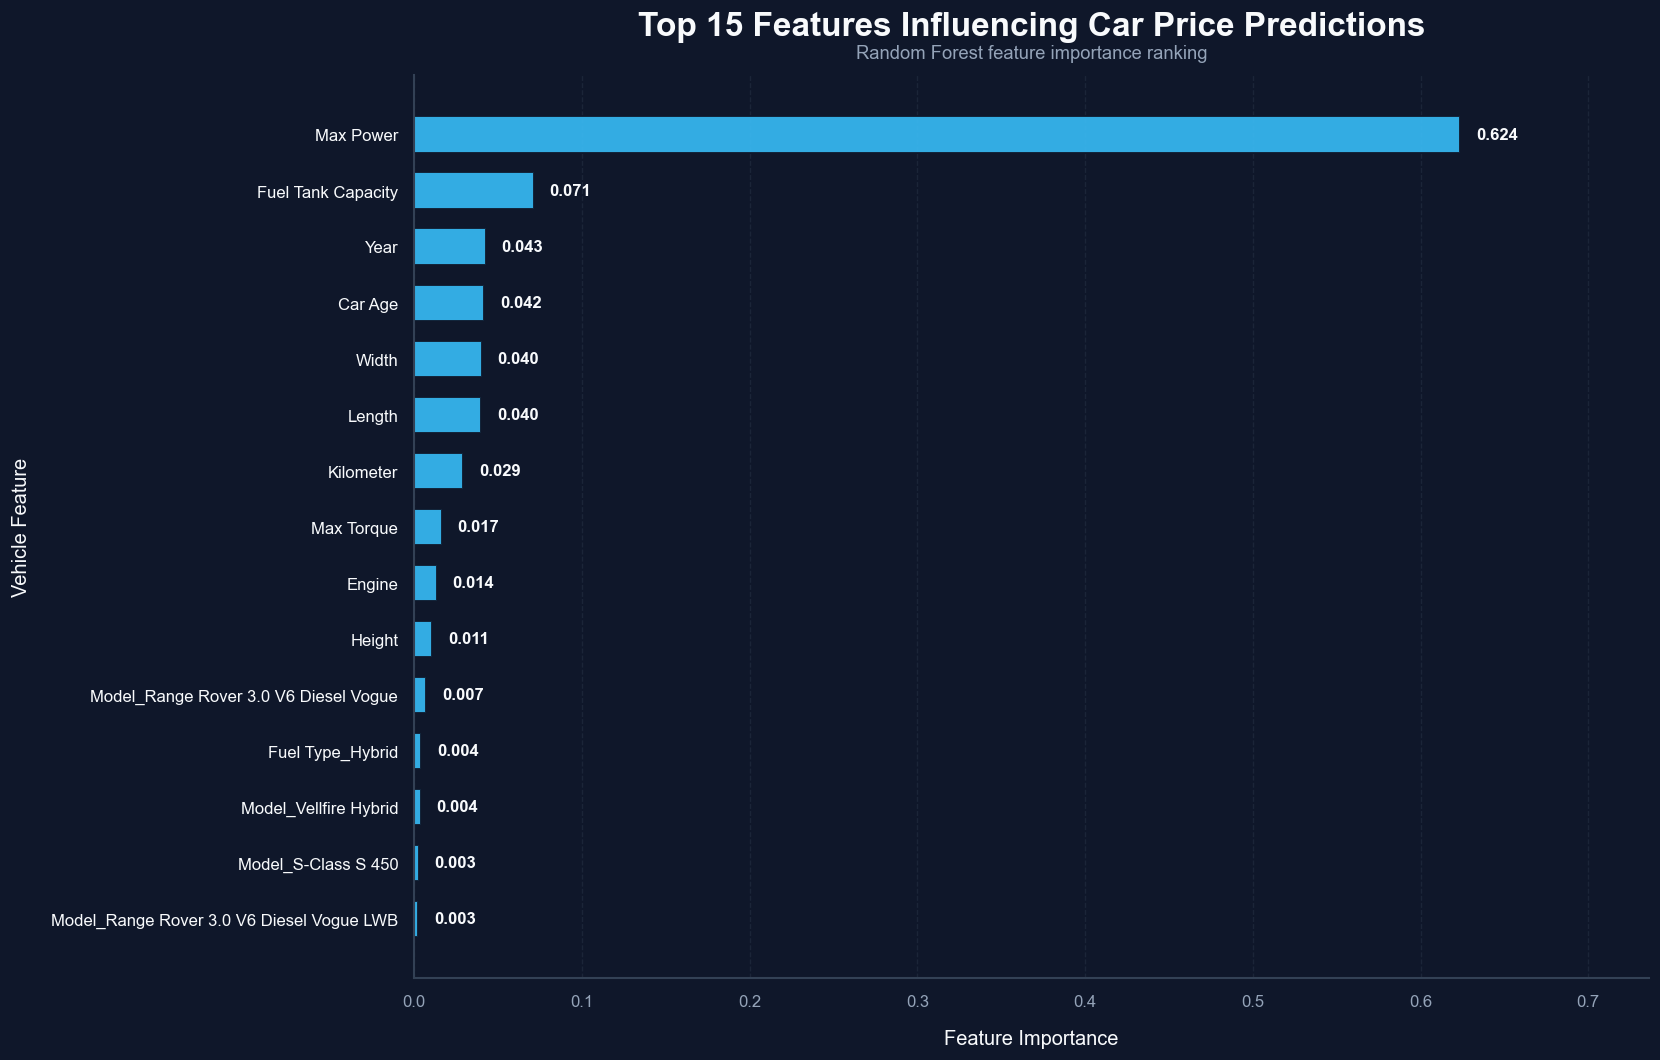

Chart saved successfully: ../images/feature_importance.png


In [54]:
# ============================================================
# 20.2 TOP 15 RANDOM FOREST FEATURE IMPORTANCES
# ============================================================

# Select the top 15 features
top_features = (
    importance_df
    .nlargest(15, "Importance")
    .sort_values("Importance", ascending=True)
    .copy()
)

# Create readable feature labels
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 9))

# Explicit background
fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["background"])

# ============================================================
# HORIZONTAL BAR CHART
# ============================================================

bars = ax.barh(
    top_features["Feature"],
    top_features["Importance"],
    height=0.65,
    color=CAR_COLORS["primary"],
    alpha=0.90,
    edgecolor=CAR_COLORS["background"],
    linewidth=1.2
)

# ============================================================
# VALUE LABELS
# ============================================================

max_importance = top_features["Importance"].max()

for bar, value in zip(bars, top_features["Importance"]):

    ax.text(
        bar.get_width() + (max_importance * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=CAR_COLORS["text"]
    )

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Top 15 Features Influencing Car Price Predictions",
    fontsize=20,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=24
)

# ============================================================
# SUBTITLE
# ============================================================

ax.text(
    0.5,
    1.015,
    "Random Forest feature importance ranking",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=CAR_COLORS["muted"]
)

# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Feature Importance",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Vehicle Feature",
    fontsize=12,
    fontweight="medium",
    color=CAR_COLORS["text"],
    labelpad=12
)

# ============================================================
# TICK FORMATTING
# ============================================================

ax.tick_params(
    axis="x",
    colors=CAR_COLORS["muted"],
    labelsize=10
)

ax.tick_params(
    axis="y",
    colors=CAR_COLORS["text"],
    labelsize=10
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="x",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

ax.grid(
    axis="y",
    visible=False
)

# ============================================================
# AXIS SPINES
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(CAR_COLORS["grid"])
ax.spines["bottom"].set_color(CAR_COLORS["grid"])

# ============================================================
# X-AXIS RANGE
# ============================================================

ax.set_xlim(
    0,
    max_importance * 1.18
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE CHART
# ============================================================

output_path = f"{IMAGE_PATH}feature_importance.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"],
    edgecolor="none"
)

plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔎 Key Observation

The Random Forest model identifies a small group of features as substantially
more influential than the remaining variables.

This indicates that vehicle characteristics such as age, mileage, engine
specifications, brand, and other vehicle attributes do not contribute equally
to price prediction.

The feature importance ranking helps identify the variables that the model
relies on most when estimating used-car prices.

> **Note:** Feature importance represents the model's predictive contribution
and does not prove that a feature directly causes a change in car price.

# 21. Residual Analysis

Residuals represent the difference between the actual and predicted selling
prices.

A residual can be calculated as:

**Residual = Actual Price − Predicted Price**

A residual plot helps identify whether prediction errors appear randomly
distributed or whether systematic patterns remain.

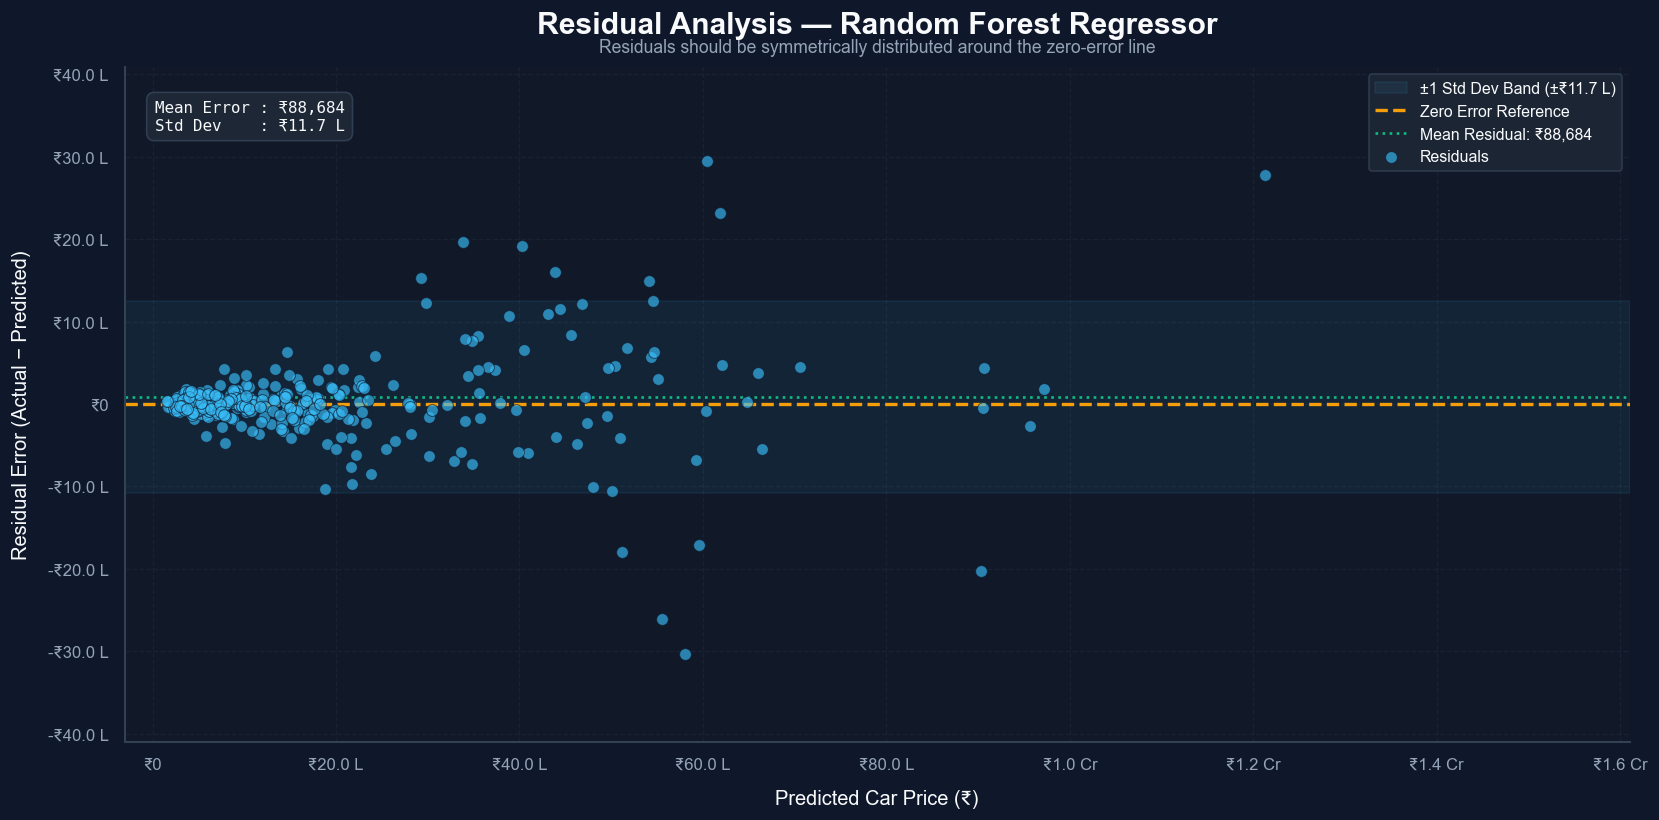

Residual analysis chart saved successfully: ../images/residual_analysis.png


In [55]:
# ============================================================
# 21.1 RESIDUAL ANALYSIS — RANDOM FOREST REGRESSOR
# ============================================================

# Calculate residuals
residuals = y_test.to_numpy() - rf_predictions
mean_residual = float(np.mean(residuals))
std_residual = float(np.std(residuals))

# Formatting helper for Indian currency denominations
def format_inr(val, pos=None):
    abs_v = abs(val)
    sign = "-" if val < 0 else ""
    if abs_v >= 10_000_000:
        return f"{sign}₹{abs_v/10_000_000:.1f} Cr"
    elif abs_v >= 100_000:
        return f"{sign}₹{abs_v/100_000:.1f} L"
    elif abs_v == 0:
        return "₹0"
    return f"{sign}₹{abs_v:,.0f}"

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

fig.patch.set_facecolor(CAR_COLORS["background"])
ax.set_facecolor(CAR_COLORS["axes"])

# ============================================================
# STANDARD DEVIATION BAND & REFERENCE LINES
# ============================================================

# Standard deviation band (±1 SD)
ax.axhspan(
    mean_residual - std_residual,
    mean_residual + std_residual,
    color=CAR_COLORS.get("primary", "#38BDF8"),
    alpha=0.08,
    label=f"±1 Std Dev Band (±{format_inr(std_residual)})",
    zorder=1
)

# Zero error line
ax.axhline(
    y=0,
    color=CAR_COLORS["warning"],
    linewidth=2.0,
    linestyle="--",
    label="Zero Error Reference",
    zorder=2
)

# Mean residual line
ax.axhline(
    y=mean_residual,
    color=CAR_COLORS.get("success", "#10B981"),
    linewidth=1.6,
    linestyle=":",
    label=f"Mean Residual: {format_inr(mean_residual)}",
    zorder=2
)

# ============================================================
# RESIDUAL SCATTER
# ============================================================

ax.scatter(
    rf_predictions,
    residuals,
    color=CAR_COLORS["primary"],
    alpha=0.65,
    s=50,
    edgecolors=CAR_COLORS["background"],
    linewidths=0.6,
    label="Residuals",
    zorder=4
)

# ============================================================
# AXIS LIMITS & FORMATTING
# ============================================================

# Symmetrical Y limits focused on the core distribution
max_abs_res = np.percentile(np.abs(residuals), 99.5) * 1.35
ax.set_ylim(-max_abs_res, max_abs_res)

# X limits with subtle margin
x_min, x_max = rf_predictions.min(), rf_predictions.max()
ax.set_xlim(x_min - (x_max - x_min) * 0.03, x_max + (x_max - x_min) * 0.03)

# Apply Lakh / Crore formatters
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_inr))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_inr))

# ============================================================
# LABELS & TITLES
# ============================================================

ax.set_title(
    "Residual Analysis — Random Forest Regressor",
    fontsize=18,
    fontweight="bold",
    color=CAR_COLORS["text"],
    pad=20
)

ax.text(
    0.5,
    1.015,
    "Residuals should be symmetrically distributed around the zero-error line",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=CAR_COLORS["muted"]
)

ax.set_xlabel(
    "Predicted Car Price (₹)",
    fontsize=12,
    color=CAR_COLORS["text"],
    labelpad=10
)

ax.set_ylabel(
    "Residual Error (Actual − Predicted)",
    fontsize=12,
    color=CAR_COLORS["text"],
    labelpad=10
)

ax.tick_params(axis="both", colors=CAR_COLORS["muted"], labelsize=10)

# ============================================================
# GRID & SPINES
# ============================================================

ax.grid(
    axis="both",
    color=CAR_COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(CAR_COLORS["grid"])
ax.spines["bottom"].set_color(CAR_COLORS["grid"])

# ============================================================
# LEGEND & STATS BOX
# ============================================================

# Residual Statistics Box
stats_text = (
    f"Mean Error : {format_inr(mean_residual)}\n"
    f"Std Dev    : {format_inr(std_residual)}"
)

ax.text(
    0.02,
    0.95,
    stats_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    fontfamily="monospace",
    color=CAR_COLORS["text"],
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#1F2937",
        edgecolor=CAR_COLORS["grid"],
        alpha=0.92
    ),
    zorder=5
)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="#1F2937",
    edgecolor=CAR_COLORS["grid"],
    fontsize=9.5
)
for text in legend.get_texts():
    text.set_color(CAR_COLORS["text"])

# ============================================================
# LAYOUT & SAVE
# ============================================================

plt.tight_layout()

output_path = "../images/residual_analysis.png"
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=CAR_COLORS["background"]
)
plt.show()

print(f"Residual analysis chart saved successfully: {output_path}")

### 🔎 Key Observation

The residual plot is used to evaluate whether the Random Forest model makes
systematic prediction errors.

Ideally, residuals should be randomly distributed around the zero-error line
without a clear pattern or trend.

A relatively balanced distribution around zero indicates that the model is
capturing the major relationships in the data, while large or structured
residual patterns may indicate areas where prediction accuracy can be improved.

# 22. Sample Price Predictions

The following table compares actual vehicle prices with prices predicted by the
Random Forest model.

This provides a simple human-readable view of model performance on unseen test
records.

In [56]:
# ============================================================
# 22.1 SAMPLE PREDICTIONS
# ============================================================

prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_predictions,
})

prediction_df["Absolute Error"] = (
    prediction_df["Actual Price"]
    - prediction_df["Predicted Price"]
).abs()

prediction_df["Actual Price"] = (
    prediction_df["Actual Price"]
    .round(2)
)

prediction_df["Predicted Price"] = (
    prediction_df["Predicted Price"]
    .round(2)
)

prediction_df["Absolute Error"] = (
    prediction_df["Absolute Error"]
    .round(2)
)

prediction_df.head(15)

,Actual Price,Predicted Price,Absolute Error
0,4800000,4948893.31,148893.31
1,825000,825206.64,206.64
2,695000,562879.99,132120.01
3,950000,966996.66,16996.66
4,819999,783339.72,36659.28
5,310000,380856.66,70856.66
6,1000000,912401.09,87598.91
7,1998999,2543823.30,544824.30
8,850000,1875716.64,1025716.64
9,3950000,5004306.66,1054306.66


# 23. Model Persistence

The trained model pipeline is saved using Joblib.

The saved pipeline contains both:

- Data preprocessing
- Machine learning model

This means the same preprocessing transformations can be applied automatically
when making predictions on new vehicle records.

In [57]:
# ============================================================
# 23.1 SAVE RANDOM FOREST PIPELINE
# ============================================================

model_file = (
    f"{MODEL_PATH}"
    "car_price_prediction_random_forest.pkl"
)

joblib.dump(
    rf_pipeline,
    model_file
)

print("Model saved successfully.")
print(f"Location: {model_file}")

Model saved successfully.
Location: ../models/car_price_prediction_random_forest.pkl


# 24. Saved Model Verification

The saved model is loaded again using Joblib and used to generate predictions.

This verifies that the persisted machine learning pipeline can be reused
without retraining the model.

In [58]:
# ============================================================
# 24.1 LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    model_file
)

loaded_predictions = loaded_model.predict(
    X_test.head(5)
)

print("Saved model loaded successfully.")

print("\nSample predictions:")
print(loaded_predictions)

Saved model loaded successfully.

Sample predictions:
[4948893.31333333  825206.64        562879.98666667  966996.66
  783339.72333333]


# 25. Final Model Summary

The machine learning experiment compared two regression approaches:

- Linear Regression
- Random Forest Regressor

The models were trained using an 80/20 train-test split and evaluated using
MAE, RMSE, and R² Score.

The final model selection is based primarily on R² while considering MAE and
RMSE as supporting error metrics.

The feature importance analysis provides additional insight into the variables
that contribute most strongly to Random Forest predictions.

In [59]:
# ============================================================
# 25.1 FINAL RESULTS
# ============================================================

best_row = results.loc[
    results["R2 Score"].idxmax()
]

print("=" * 65)
print("FINAL MODEL PERFORMANCE")
print("=" * 65)

print(f"\nBest Model : {best_row['Model']}")
print(f"MAE        : {best_row['MAE']:,.2f}")
print(f"RMSE       : {best_row['RMSE']:,.2f}")
print(f"R² Score   : {best_row['R2 Score']:.4f}")

FINAL MODEL PERFORMANCE

Best Model : Random Forest Regressor
MAE        : 297,043.07
RMSE       : 1,168,553.45
R² Score   : 0.8045


In [60]:
# Create outputs folder if it does not exist
os.makedirs("../outputs", exist_ok=True)

# ----------------------------------------------------------
# Save Model Comparison
# ----------------------------------------------------------
results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

# ----------------------------------------------------------
# Save Sample Predictions
# ----------------------------------------------------------
prediction_df.to_csv(
    "../outputs/sample_predictions.csv",
    index=False
)

# ----------------------------------------------------------
# Save Top Feature Importance
# ----------------------------------------------------------
importance_df.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

print("=" * 55)
print("Project outputs exported successfully.")
print("=" * 55)
print("Saved Files:")
print("✓ model_comparison.csv")
print("✓ sample_predictions.csv")
print("✓ feature_importance.csv")

Project outputs exported successfully.
Saved Files:
✓ model_comparison.csv
✓ sample_predictions.csv
✓ feature_importance.csv


# 26. Final Conclusion

## 🎯 Project Outcome

This project successfully developed an end-to-end machine learning workflow
for used-car price prediction.

The project covered:

- Data inspection
- Data cleaning
- Missing-value handling
- Duplicate removal
- Categorical standardization
- Feature engineering
- Exploratory data analysis
- Numerical feature preparation
- One-hot encoding
- Train-test splitting
- Linear Regression
- Random Forest Regression
- MAE, RMSE, and R² evaluation
- Model comparison
- Feature importance analysis
- Actual vs predicted analysis
- Residual analysis
- Model persistence using Joblib

## 🤖 Model Selection

Two regression models were evaluated on unseen test data.

The model with the strongest overall evaluation metrics was selected as the
preferred model for this dataset.

The final decision should be based on the actual evaluation results rather than
assuming that a particular algorithm will always perform better.

## 💡 Business Insights

The model and exploratory analysis can help understand how factors such as
vehicle age, mileage, brand, engine specifications, fuel type, and transmission
relate to used-car pricing.

These insights can support data-driven vehicle valuation and pricing decisions.

## 🚀 Future Improvements

Possible improvements include:

- Hyperparameter tuning
- Cross-validation
- Gradient Boosting / XGBoost
- Advanced feature engineering
- Outlier treatment
- Log transformation of highly skewed prices
- Explainable AI using SHAP
- Model deployment through an API
- Interactive prediction interface

## ✅ Final Status

**Task 3 — Car Price Prediction: Completed**

The project is structured as a reproducible machine learning workflow and is
ready for documentation, GitHub submission, and demonstration.